# Flow in the Viane experience-sampling data

### Operationalization, analysis, and conclusions

---

## Purpose of this notebook

This is the reporting layer for the flow analysis. It presents, in one readable document, what the
construct is, how it was operationalized, which methodological choices were made and why, what the
models found, and what those findings do and do not license.

**All models are estimated by the analysis scripts in `../scripts/`.** This notebook does not
re-fit anything. It reads their output tables, renders them, draws the figures, and interprets the
results. Every number shown is traced
to the script and the file that produced it; Appendix A is the complete provenance map.

## How to read it

| Section | What it answers |
| --- | --- |
| 1 | What flow is, and which items measure it here |
| 2 | The analytic dataset: sample, compliance, missingness |
| 3 | The standardization decision, and why it is the most consequential one |
| 4 | How the flow variables are built |
| 5 | **V1, prevalence.** Does this population experience flow at all, and how often? |
| 6 | **V2, the model.** Does the challenge-skill configuration predict the flow experience? |
| 7 | **V3, dynamics.** Is there temporal structure, and does the relation differ per person? |
| 8 | Flow and the momentary experience of pain |
| 9 | Flow proneness and baseline trait profiles |
| 10 | Robustness: do the conclusions survive the alternative choices? |
| 11 | Decision log |
| 12 | Conclusions |
| 13 | Caveats |
| A | Provenance: which script and which file produced each result |

## Findings in brief

1. **The construct is available and the operationalization is sound.** Four momentary items cover
   the antecedent condition and the core experience. 5,976 moments in 68 persons, with roughly 78
   percent of the variance in every item sitting within person.
2. **The flow model holds only half.** The challenge-skill condition predicts the flow experience
   very strongly, but entirely through *elevation* (both high) and not through *balance* (matched).
   Between persons, and on the raw scale, the balance effect is significantly negative, which is a
   reversal of the theory rather than an absence of support.
3. **Flow relates to the momentary experience of pain, concurrently and significantly.** Lower
   pain, lower interference, less attention to pain, and lower threat, all p < .001 and all
   unchanged after adjusting for physical activation.
4. **Temporal structure is essentially absent.** Inside the flow model the lagged condition effect
   is marginal (p = .062) and about 6 percent of the concurrent one. Between flow and pain there is
   nothing at lag 1 in either direction.
5. **The flow-pain association is strongly person-specific.** 73 percent of participants show the
   negative pattern, 14 of 63 reliably so, but 4 show a reliably positive one.
6. **The relaxation channel outperforms flow on every pain outcome.** In chronic pain the
   protective ingredient looks like competence without demand, not optimal challenge.

---
# 0. Setup

Two things are loaded: the scripts' result tables, and the derived analytic frame they persisted. The frame is used only for descriptive plots (distributions, the flow surface, the
per-person prevalence bars); every estimate comes from the tables.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# This notebook lives at src/utils/pipeline/separate/12_flow_states/flow_analysis/
ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

TABLES = ROOT / "src" / "results" / "tables"
MODELS = ROOT / "src" / "results" / "models"
FIGDIR = Path.cwd() / "figures"
FIGDIR.mkdir(exist_ok=True)


def T(name):
    '''Read a stage-12 result table produced by the R pipeline.'''
    return pd.read_csv(TABLES / f"12_flow_{name}.csv")


# The derived analytic frame: one row per moment, with every flow variable already built.
frame = pd.read_csv(MODELS / "12_flow_analytic_frame.csv")

print("project root  :", ROOT)
print("result tables :", len(list(TABLES.glob("12_flow_*.csv"))), "stage-12 files")
print("analytic frame:", f"{len(frame):,} moments x {frame.shape[1]} columns")

project root  : /Users/stijnvanseveren/PROJECTS/summer_2026/CROMBEZ_MAP/04_Viane_EMA
result tables : 24 stage-12 files
analytic frame: 5,976 moments x 59 columns


In [2]:
# Visual identity, matched to the manuscript figures so panels can be lifted directly.
INK, MUTED, GRID = "#1d2733", "#5b6b7b", "#dfe5ec"
COL = {"PIJN": "#c1483f", "THREAT": "#9b59b6", "ATTEND": "#2a7f9e",
       "ENGAGE": "#3a9e6e", "EFFIC": "#d98a3d", "VALENCE": "#8a6d3b",
       "CHALLENGE": "#7a5ea8", "FLOWEXP": "#4f8f5a",
       "balance": "#6b8fae", "elevation": "#c98a2b"}
CHANNEL_COL = {"Flow": "#3a9e6e", "Relaxation": "#6b8fae",
               "Anxiety": "#c1483f", "Apathy": "#9aa5b1"}
CHANNELS = ["Flow", "Relaxation", "Anxiety", "Apathy"]
LABEL = {"PIJN": "Pain intensity", "PIJN_AFF": "Pain interference",
         "ATTEND": "Attention to pain", "THREAT": "Threat value",
         "CHALLENGE": "Challenge", "EFFIC": "Skill", "ENGAGE": "Absorption",
         "VALENCE": "Enjoyment", "FLOWEXP": "Flow experience",
         "NEGAFF": "Negative affect", "POSAFF": "Positive affect",
         "ACTIEF": "Physical activation"}
ITEMS = ["CHALLENGE", "EFFIC", "ENGAGE", "VALENCE"]
OUTCOMES = ["PIJN", "PIJN_AFF", "ATTEND", "THREAT"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 9})


def panel(ax, letter, dx=-0.10, dy=1.08):
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="right", color=INK)


def bar_axes(ax, horizontal=False):
    ax.grid(axis="x" if horizontal else "y", visible=True)
    ax.grid(axis="y" if horizontal else "x", visible=False)


def matrix_axes(ax):
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(length=0)


def show(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    plt.show()


def fmt_p(p):
    '''p values as reported in the manuscript style.'''
    if pd.isna(p):
        return ""
    return "<.001" if float(p) < .001 else f"{float(p):.3f}".lstrip("0")

---
# 1. The construct and the instrument

## 1.1 Definition

Flow, in Csikszentmihalyi's sense, is a state of **deep absorption and effortless concentration**
that arises when perceived challenge and perceived skill are both high and roughly matched, and
that is experienced as intrinsically rewarding, or autotelic.

The construct has two structurally distinct parts, and keeping them apart drives every
methodological choice that follows:

- an **antecedent condition**, the configuration of challenge and skill, and
- the **experience** itself, absorption plus enjoyment.

Collapsing the two into one sum score conflates the cause with the outcome. It is never done here.

## 1.2 The four items

All four are 7-point momentary appraisals of the activity the participant was engaged in at the
beep, anchored "not at all" to "very much". Challenge and skill descend from the Delespaul ESM
tradition; absorption and enjoyment were assigned by the original authors to Klinger's
goal-directed framework.

| Facet, and its role in the flow model | Item (EN) | Item (NL) | Column (raw) |
| --- | --- | --- | --- |
| Challenge, antecedent condition | This activity is a personal challenge to me | Deze activiteit is een persoonlijke uitdaging voor mij | `CHALLENGE` (`ACT_UITD`) |
| Skill / efficacy, antecedent condition | I am good at it | Ik kan dit goed | `EFFIC` (`ACT_SUC`) |
| Absorption / engagement, core experience | I am absorbed in this activity | Ik ga op in deze activiteit | `ENGAGE` (`ACT_AAND`) |
| Valence / enjoyment, autotelic marker | I like doing this | Ik doe dit graag | `VALENCE` (`ACT_MOT`) |

A fifth activity item, goal importance (`ACT_INSP`), exists. It belongs to the Klinger goal
framework rather than to flow and is not part of any flow index here.

## 1.3 Coverage against the nine flow dimensions

This determines how the construct may be labelled.

| Csikszentmihalyi dimension | Measured here? |
| --- | --- |
| Challenge-skill balance | Yes, directly |
| Concentration, action-awareness merging | Partly, through absorption |
| Autotelic experience | Partly, through enjoyment |
| Clear goals | No. A goal-importance item exists, but importance is not clarity |
| Unambiguous feedback | No |
| Sense of control | No. The control items in this dataset concern control over *pain*, not over the task |
| Loss of self-consciousness | No |
| Time transformation | No |
| Intrinsic reward | Partly, through enjoyment |

**Consequence.** Three of nine dimensions plus the defining antecedent condition, from four single
items. The honest label is a **core flow proxy**, never "a measure of flow". This is not a weakness
peculiar to this dataset: the ESM flow tradition (Massimini and Carli, 1988; Moneta and
Csikszentmihalyi, 1996) has always measured flow from exactly challenge, skill, and a small set of
experience items. Full multi-item instruments such as the Flow State Scale-2 exist, but no ESM
protocol of this vintage carried them.

## 1.4 Provenance of the measure

The original study analysed these four items **separately** and never combined them into a flow
score. Every index in this notebook is therefore a secondary, analyst-constructed measure and is
reported as such. This is an analysis decision, not a re-coding of the source data.

## 1.5 Key references

- Csikszentmihalyi, M. (1990). *Flow: The Psychology of Optimal Experience*. Harper & Row.
- Csikszentmihalyi, M., & Larson, R. (1987). *Journal of Nervous and Mental Disease*, 175(9),
  526-536. [doi:10.1097/00005053-198709000-00004](https://doi.org/10.1097/00005053-198709000-00004)
- Massimini, F., & Carli, M. (1988). In *Optimal Experience*. Cambridge University Press.
  [doi:10.1017/CBO9780511621956.014](https://doi.org/10.1017/CBO9780511621956.014)
- Moneta, G. B., & Csikszentmihalyi, M. (1996). *Journal of Personality*, 64(2), 275-310.
  [doi:10.1111/j.1467-6494.1996.tb00512.x](https://doi.org/10.1111/j.1467-6494.1996.tb00512.x)
- Fong, C. J., Zaleski, D. J., & Leach, J. K. (2015). *Journal of Positive Psychology*, 10(5),
  425-446. [doi:10.1080/17439760.2014.967799](https://doi.org/10.1080/17439760.2014.967799)
- Nakamura, J., & Csikszentmihalyi, M. (2014). In *Flow and the Foundations of Positive
  Psychology*. Springer.
  [doi:10.1007/978-94-017-9088-8_16](https://doi.org/10.1007/978-94-017-9088-8_16)
- Jackson, S. A., & Eklund, R. C. (2002). *Journal of Sport and Exercise Psychology*, 24(2),
  133-150. [doi:10.1123/jsep.24.2.133](https://doi.org/10.1123/jsep.24.2.133)
- Curran, P. J., & Bauer, D. J. (2011). *Annual Review of Psychology*, 62, 583-619.
  [doi:10.1146/annurev.psych.093008.100356](https://doi.org/10.1146/annurev.psych.093008.100356)
- Gromakovskis, V., & Gutmanis, M. G. (2025). *Journal of Pain Research*, 18, 6723-6743.
  [doi:10.2147/JPR.S564395](https://doi.org/10.2147/JPR.S564395)
- Eccleston, C., & Crombez, G. (1999). *Psychological Bulletin*, 125(3), 356-366.
  [doi:10.1037/0033-2909.125.3.356](https://doi.org/10.1037/0033-2909.125.3.356)
- Van Damme, S., Legrain, V., Vogt, J., & Crombez, G. (2010). *Neuroscience and Biobehavioral
  Reviews*, 34(2), 204-213.
  [doi:10.1016/j.neubiorev.2009.01.005](https://doi.org/10.1016/j.neubiorev.2009.01.005)
- Viane, I., Crombez, G., Eccleston, C., Devulder, J., & De Corte, W. (2004). *Pain*, 112(3),
  282-288. [doi:10.1016/j.pain.2004.09.008](https://doi.org/10.1016/j.pain.2004.09.008)

---
# 2. The analytic dataset

Four preparatory questions have to be settled before any modelling: what counts as a valid
response, what compliance minimum applies, how the nesting is handled, and whether missingness is
informative.

In [3]:
n_per = frame.groupby("pid").size()
print(f"analytic frame : {len(frame):,} moments, {frame['pid'].nunique()} persons")
print(f"per person     : median {n_per.median():.0f}, "
      f"IQR {n_per.quantile(.25):.0f} to {n_per.quantile(.75):.0f}, "
      f"range {n_per.min()} to {n_per.max()}")

desc = T("item_descriptives").rename(columns={
    "variable": "item", "role": "role", "n": "n", "mean": "M", "sd": "SD",
    "icc_person": "ICC (person)", "within_share": "within-person share"})
desc["item"] = desc["item"].map(LABEL)
display(desc)

analytic frame : 5,976 moments, 68 persons
per person     : median 92, IQR 82 to 99, range 25 to 121


,item,role,n,M,SD,ICC (person),within-person share
0,Challenge,Condition,6165,3.28,1.98,0.242,0.758
1,Skill,Condition,6108,4.79,1.55,0.226,0.774
2,Absorption,Experience,6143,4.00,1.90,0.213,0.787
3,Enjoyment,Experience,6136,4.90,1.58,0.207,0.793
4,Flow experience,Experience,6035,4.45,1.51,0.201,0.799


**Feasibility, settled.** Every flow item has an ICC around .20 to .24, so roughly 76 to 80 percent
of its variance is within person. Flow in this dataset is a genuinely fluctuating momentary state,
not a disguised trait. This is the precondition for the whole analysis and it is met comfortably.

Two descriptive facts already matter. Challenge has the lowest mean of the four (3.28) and the
widest spread: these participants mostly do things they do not find challenging. Skill and
enjoyment are high (4.79 and 4.90). The typical moment in this sample therefore sits closer to the
relaxation corner of the flow plane than to the flow corner.

## 2.1 Valid response

The intended rule was to keep beep answers given inside a 15-minute protocol window and treat late
or absent beeps as missing.

**This could not be applied.** The raw day file (`src/data/raw/diary_day.sav`) contains a single
time variable, `UUR`, recording the clock time of the *entry*. There is no separate signal
timestamp, so response latency is not recoverable.

**Decision taken.** Use the project's existing definition of a completed prompt, namely that the
core pain item was answered. This has the side benefit that the flow analysis runs on exactly the
same sample as the rest of the study, so estimates are directly comparable across sections. A
documented deviation forced by the archive rather than chosen, and it belongs in the limitations.

## 2.2 Compliance minimum

The specification suggests at least 20 to 30 valid moments per person before a person-level
estimate is trusted.

**Decision taken: 50 moments**, the project's existing idiographic floor. Stricter than the
suggestion, and consistent with the idiographic stages of the study. The multilevel models use
every participant, because partial pooling stabilises short series; the per-person analyses in
section 7 apply the 50-moment floor. Section 10.4 re-runs the headline result at 20, 30, 50, and 70.

## 2.3 Nesting

Moments (level 1) nested in persons (level 2), with participant random effects throughout. Day in
study and beep number are available as level-1 covariates; section 10.3 shows that adding them
leaves the focal estimates unchanged, so the reported models omit them for readability.

## 2.4 Missingness

In a chronic pain sample, non-response may be informative: high-pain, low-activity moments are
plausibly the ones most likely to be skipped. If so, flow prevalence would be biased upward.

In [4]:
miss = T("missingness")
print(f"listwise loss: {miss['n_moments_dropped'].iloc[0]:,} moments "
      f"({miss['pct_dropped'].iloc[0]}% of completed prompts)")
mm = miss[["variable", "mean_present", "mean_missing", "n_missing", "cohens_d", "p"]].copy()
mm["variable"] = mm["variable"].map(LABEL)
mm["p"] = mm["p"].map(fmt_p)
mm.columns = ["variable", "flow items present", "flow items missing", "n missing",
              "Cohen d", "p"]
display(mm)

listwise loss: 286 moments (4.57% of completed prompts)


,variable,flow items present,flow items missing,n missing,Cohen d,p
0,Pain intensity,4.53,4.36,286,-0.115,.052
1,Pain interference,3.86,3.79,272,-0.043,.476
2,Attention to pain,2.89,2.95,255,0.034,.593
3,Threat value,2.23,2.44,268,0.151,.019
4,Negative affect,1.92,2.14,280,0.193,.002
5,Positive affect,4.23,4.27,286,0.033,.583
6,Physical activation,3.05,2.62,274,-0.235,<.001


**Reading of the missingness check.** Listwise deletion removes 4.6 percent of completed prompts
(286 moments). Those moments are not a random subset, but the pattern is mild and specific.
Skipped moments carry slightly more threat (d = 0.15, p = .019) and negative affect (d = 0.19,
p = .002), and are notably **less** physically active (d = -0.24, p < .001). Pain intensity is
marginally *lower* rather than higher (d = -0.12, p = .052), and interference, attention, and
positive affect do not differ.

So the skipped moments look like quieter, more distressed, less active moments, not the
high-pain crises the specification warns about. Two consequences. First, prevalence figures in
section 5 may be very slightly optimistic, since inactive moments are under-represented and those
are the least flow-like. Second, because the deviation is on threat and activation rather than on
pain, the concurrent flow-pain estimate in section 8 is unlikely to be materially biased.

---
# 3. The standardization decision

This is the single choice that most often produces interpretation errors in ESM flow research, so
it is settled explicitly, before anything is estimated.

**The problem.** Within-person z-scoring sets every person's mean to exactly zero. Any rule of the
form "challenge above the person's own average and skill above the person's own average" therefore
assigns above-average moments to *everyone*, including someone who was never in flow in any
absolute sense. For a prevalence question that is a structural bias, not a technicality.

## The four options

| | What it does | Pro | Con |
| --- | --- | --- | --- |
| **A. Raw absolute** (thresholds on 1 to 7) | keeps the absolute level | a person genuinely *can* have zero flow moments; directly interpretable on the response scale; comparable across persons | sensitive to response style and range restriction; the threshold (4 or 5) is arbitrary and matters a lot |
| **B. Grand-mean z** (pooled over the sample) | one common metric | keeps between-person level differences; simple | does not correct response style; z is relative to *this* sample; mixes within and between variance in one number |
| **C. Within-person z** | removes response style and personal scale calibration | the ESM flow standard; ideal for within-person relations | forces a relative distribution, so it manufactures flow moments for everyone; ipsative and not comparable across persons; unstable with few moments |
| **D. Person-mean centering** (within-between decomposition) | splits the person mean from the momentary deviation | answers the prevalence and the dynamics question separately; the multilevel standard (Curran and Bauer, 2011); combines cleanly with random slopes | more complex to report; the between component is still response-style sensitive |

## Decision taken

**D as the primary metric, A for every prevalence claim, B and C as sensitivity analyses.** Section
10.1 refits the main model on all four.

C and D produce **identical channel assignments**, because within-person z is a positive rescaling
of the person-mean-centred score and cannot change the sign of a deviation. They differ only in the
size of the coefficients, which is why both appear in the sensitivity table but give one prevalence
row each with identical counts.

The table below is the empirical justification for the decision.

In [5]:
prev = T("prevalence_by_rule")
demo = prev[["rule_label", "moments_condition", "person_min", "n_persons_zero",
             "n_persons"]].copy()
for c in ["moments_condition", "person_min"]:
    demo[c] = (100 * demo[c]).round(1)
demo.columns = ["standardization rule", "% of moments in flow", "lowest person %",
                "persons at exactly 0%", "n persons"]
display(demo)

,standardization rule,% of moments in flow,lowest person %,persons at exactly 0%,n persons
0,"A. Absolute, both items >= 4",39.6,1.0,0,68
1,"A. Absolute, both items >= 5",22.0,0.0,4,68
2,"B. Grand-mean z, above the sample mean",30.6,0.0,2,68
3,"C. Within-person z, above own mean",28.9,1.0,0,68
4,"D. Person-mean centered, above own mean",28.9,1.0,0,68


**This table is the argument.** Under the strict absolute rule, three participants never once rate
both challenge and skill at 5 or above, and a fourth drops out once the experience gate is applied
in section 5. For them the honest answer to "does this person experience flow" is no. Under
within-person z and person-mean centering, **zero** participants are at zero and even the lowest
person is credited with 1 percent of their moments as flow. The relative metrics cannot represent
absence: they are the right tool for within-person dynamics and the wrong tool for prevalence.

---
# 4. Building the flow variables

## 4.1 The condition: balance and elevation, not a sum

Challenge and skill do not combine linearly. High challenge with low skill is anxiety; low
challenge with high skill is relaxation or boredom; both low is apathy. A simple sum of challenge
and skill is therefore **not** a flow condition.

Two parameterizations are carried.

**Option 1, the categorical quadrant** (Massimini and Carli, 1988). A moment is flow when challenge
and skill are both above a cut, and anxiety, relaxation, or apathy otherwise. Established and easy
to communicate, but it dichotomises continuous information and loses power.

**Option 2, continuous balance and elevation** (Moneta and Csikszentmihalyi, 1996), the primary
specification:

$$\text{balance} = -\lvert \text{challenge} - \text{skill}\rvert \qquad
\text{elevation} = \frac{\text{challenge} + \text{skill}}{2}$$

Balance is higher when the two are better matched; elevation is higher when both are high. **The
elevation term is not optional**: balance on its own would score a low-challenge, low-skill moment,
that is apathy, as perfectly balanced.

## 4.2 The experience: absorption gated by enjoyment

$$\text{flow experience} = \frac{\text{absorption} + \text{enjoyment}}{2}$$

The enjoyment term matters especially in a pain context, where high challenge can coincide with
threat and effortful struggle rather than positive engrossment. Enjoyment is what separates flow
from grinding.

## 4.3 Index versus model

Both routes are implemented, because they answer different questions.

- **Gated flow index**, descriptive, for V1. A moment counts as flow when the challenge-skill
  condition is met **and** the flow experience is high. The gate blocks the "balanced but
  disengaged" false positive an unguarded quadrant produces.
- **Model test**, explanatory and stronger, for V2. Condition as predictor, experience as outcome,
  multilevel with random slopes. This tests whether the flow model holds without assigning flow
  moments to anybody by construction.

**Never done: summing the four items into one score.**

## 4.4 What the pipeline builds

`src/utils/lib/common.R::build_flow()` adds every derived variable on four metrics, and
`flow_channel()` performs the quadrant classification. Column suffixes:

| Suffix | Metric |
| --- | --- |
| none | A, raw 1 to 7 |
| `_gz` | B, grand-mean z over the whole sample |
| `_z` | C, within-person z |
| `_w` | D, within component, person-mean centred |
| `_b` | D, between component, the person mean |

In [6]:
cols = ["CHALLENGE", "EFFIC", "ENGAGE", "VALENCE", "FLOWEXP",
        "balance_w", "elevation_w", "chan_D_center", "flow_gated_A_abs5"]
display(frame[cols].head())

corr = T("item_correlations")
vl = ITEMS + ["FLOWEXP"]
wi = corr[corr["level"] == "within"].set_index("variable")[vl].loc[vl].values
be = corr[corr["level"] == "between"].set_index("variable")[vl].loc[vl].values
print("\nItem intercorrelations, within person (lower) and between person (upper):")

,CHALLENGE,EFFIC,ENGAGE,VALENCE,FLOWEXP,balance_w,elevation_w,chan_D_center,flow_gated_A_abs5
0,1,3,4,4,4.0,-0.064161,-1.394149,Apathy,0
1,1,7,7,7,7.0,-3.935839,0.605851,Relaxation,0
2,1,4,4,4,4.0,-0.935839,-0.894149,Apathy,0
3,1,5,7,7,7.0,-1.935839,-0.394149,Relaxation,0
4,1,6,7,6,6.5,-2.935839,0.105851,Relaxation,0



Item intercorrelations, within person (lower) and between person (upper):


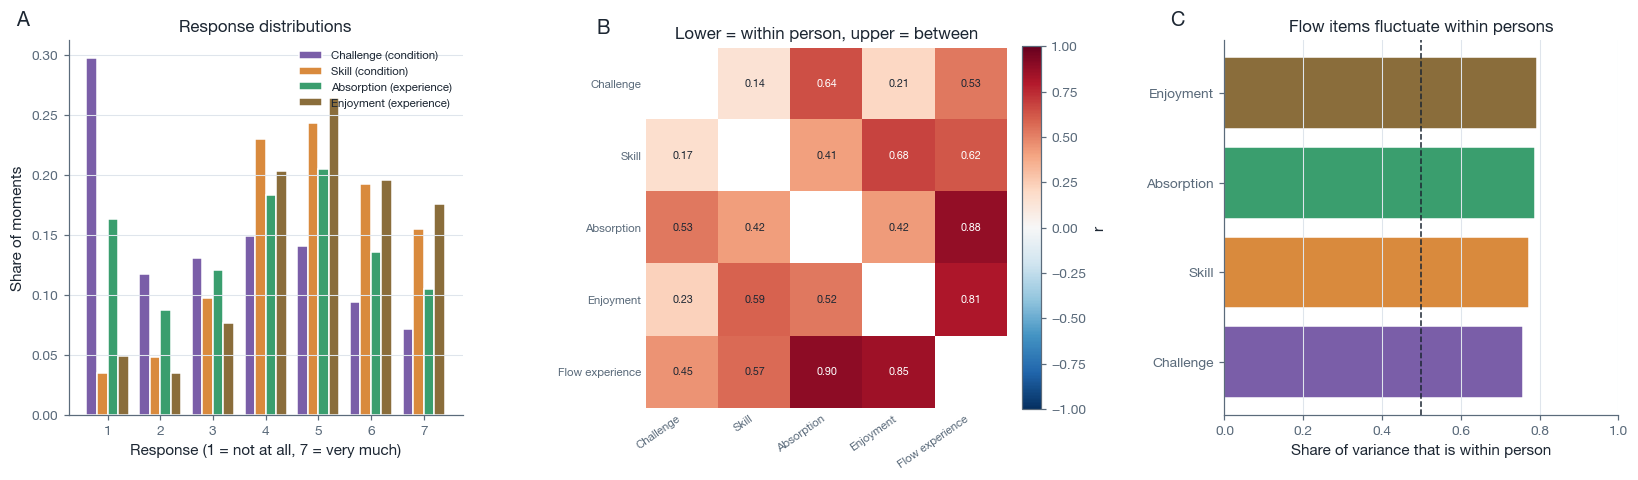

In [7]:
# Figure 1. The instrument.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

a = ax[0]
w = 0.2
for k, it in enumerate(ITEMS):
    share = frame[it].value_counts(normalize=True).reindex(range(1, 8), fill_value=0)
    role = "condition" if it in ("CHALLENGE", "EFFIC") else "experience"
    a.bar(np.arange(1, 8) + (k - 1.5) * w, share.values, w, color=COL[it],
          edgecolor="white", label=f"{LABEL[it]} ({role})")
a.set_xticks(range(1, 8))
a.set_xlabel("Response (1 = not at all, 7 = very much)")
a.set_ylabel("Share of moments")
a.set_title("Response distributions")
a.legend(fontsize=7.5)
bar_axes(a); panel(a, "A")

a = ax[1]
M = np.tril(wi, -1) + np.triu(be, 1) + np.diag(np.full(len(vl), np.nan))
im = a.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
labs = [LABEL[v] for v in vl]
a.set_xticks(range(len(vl))); a.set_yticks(range(len(vl)))
a.set_xticklabels(labs, rotation=35, ha="right", fontsize=7.5)
a.set_yticklabels(labs, fontsize=7.5)
for i in range(len(vl)):
    for j in range(len(vl)):
        if np.isfinite(M[i, j]):
            a.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7,
                   color=INK if abs(M[i, j]) < 0.6 else "white")
a.set_title("Lower = within person, upper = between")
matrix_axes(a); fig.colorbar(im, ax=a, fraction=0.046, pad=0.04, label="r")
panel(a, "B")

a = ax[2]
dd = T("item_descriptives")
dd = dd[dd["variable"] != "FLOWEXP"]
a.barh([LABEL[v] for v in dd["variable"]], dd["within_share"],
       color=[COL[v] for v in dd["variable"]], edgecolor="white")
a.axvline(0.5, color=INK, ls="--", lw=1.0)
a.set_xlim(0, 1)
a.set_xlabel("Share of variance that is within person")
a.set_title("Flow items fluctuate within persons")
bar_axes(a, horizontal=True); panel(a, "C")

fig.tight_layout(w_pad=2.6)
show(fig, "fig01_instrument")

**Figure 1 in words.** Panel A: challenge is strongly skewed toward the low end, the other three
toward the high end. Panel B: the two condition items are nearly independent of one another
(within-person r = .17), which is what makes the quadrant classification informative rather than
degenerate; the two experience items correlate .52 within person, high enough to justify a
composite and low enough that the enjoyment gate still adds information. Panel C: all four items
are dominated by within-person variance.

---
# 5. V1, prevalence

> **V1. Prevalence and presence.** Does this chronic pain population experience flow at all, and
> how often? This requires absolute level information; within-person standardization is
> unsuitable here.

**Method the question dictates.** Metric A (raw absolute thresholds), the gated index rather than
the bare quadrant, and a per-person distribution that **includes the zeros**. A prevalence figure
that cannot represent absence is not a prevalence figure. Metrics B, C, and D are shown alongside
only to demonstrate what they would have claimed.

**Produced by** `01_flow_construct.R`, section 2.

In [8]:
prev = T("prevalence_by_rule")
tab = prev[["rule_label", "moments_condition", "moments_gated", "person_median",
            "person_min", "person_max", "n_persons_zero"]].copy()
tab["gate removes"] = (100 * (tab["moments_condition"] - tab["moments_gated"])).round(1)
for c in ["moments_condition", "moments_gated", "person_median", "person_min", "person_max"]:
    tab[c] = (100 * tab[c]).round(1)
tab = tab[["rule_label", "moments_condition", "moments_gated", "gate removes",
           "person_median", "person_min", "person_max", "n_persons_zero"]]
tab.columns = ["standardization rule", "condition met %", "gated flow %", "gate removes (pp)",
               "median person %", "min person %", "max person %", "persons at 0"]
display(tab)

,standardization rule,condition met %,gated flow %,gate removes (pp),median person %,min person %,max person %,persons at 0
0,"A. Absolute, both items >= 4",39.6,36.8,2.8,35.0,1.0,89.4,0
1,"A. Absolute, both items >= 5",22.0,19.3,2.7,16.4,0.0,66.7,4
2,"B. Grand-mean z, above the sample mean",30.6,27.8,2.8,26.7,0.0,75.0,2
3,"C. Within-person z, above own mean",28.9,24.6,4.3,24.5,1.0,53.2,0
4,"D. Person-mean centered, above own mean",28.9,24.6,4.3,24.5,1.0,53.2,0


In [9]:
# Momentary profile of each channel, under the strict absolute rule and the centred rule.
prof = T("channel_profiles")
prof = prof[prof["rule"].isin(["A_abs5", "D_center"])].copy()
keep = ["rule_label", "channel", "n", "share", "mean_pijn", "mean_pijn_aff", "mean_attend",
        "mean_threat", "mean_flowexp", "mean_negaff", "mean_posaff", "mean_actief"]
prof = prof[keep]
prof["share"] = (100 * prof["share"]).round(1)
prof.columns = ["rule", "channel", "n", "%", "Pain", "Interference", "Attention", "Threat",
                "Flow experience", "Neg affect", "Pos affect", "Activation"]
display(prof)

,rule,channel,n,%,Pain,Interference,Attention,Threat,Flow experience,Neg affect,Pos affect,Activation
4,"A. Absolute, both items >= 5",Flow,1314,22.0,4.90,4.15,2.99,2.34,5.79,1.87,4.43,4.33
5,"A. Absolute, both items >= 5",Relaxation,2214,37.0,4.29,3.52,2.69,2.09,4.64,1.79,4.43,2.47
6,"A. Absolute, both items >= 5",Anxiety,516,8.6,4.83,4.28,3.11,2.23,4.44,2.06,3.99,4.44
7,"A. Absolute, both items >= 5",Apathy,1932,32.3,4.49,3.94,3.00,2.31,3.33,2.05,3.92,2.46
16,"D. Person-mean centered, above own mean",Flow,1726,28.9,4.59,3.88,2.96,2.32,5.46,1.92,4.35,4.01
17,"D. Person-mean centered, above own mean",Relaxation,1615,27.0,4.26,3.55,2.67,2.05,4.54,1.79,4.38,2.21
18,"D. Person-mean centered, above own mean",Anxiety,1074,18.0,4.69,4.12,3.03,2.34,4.34,2.04,4.10,3.99
19,"D. Person-mean centered, above own mean",Apathy,1561,26.1,4.65,3.99,2.95,2.22,3.31,1.96,4.03,2.19


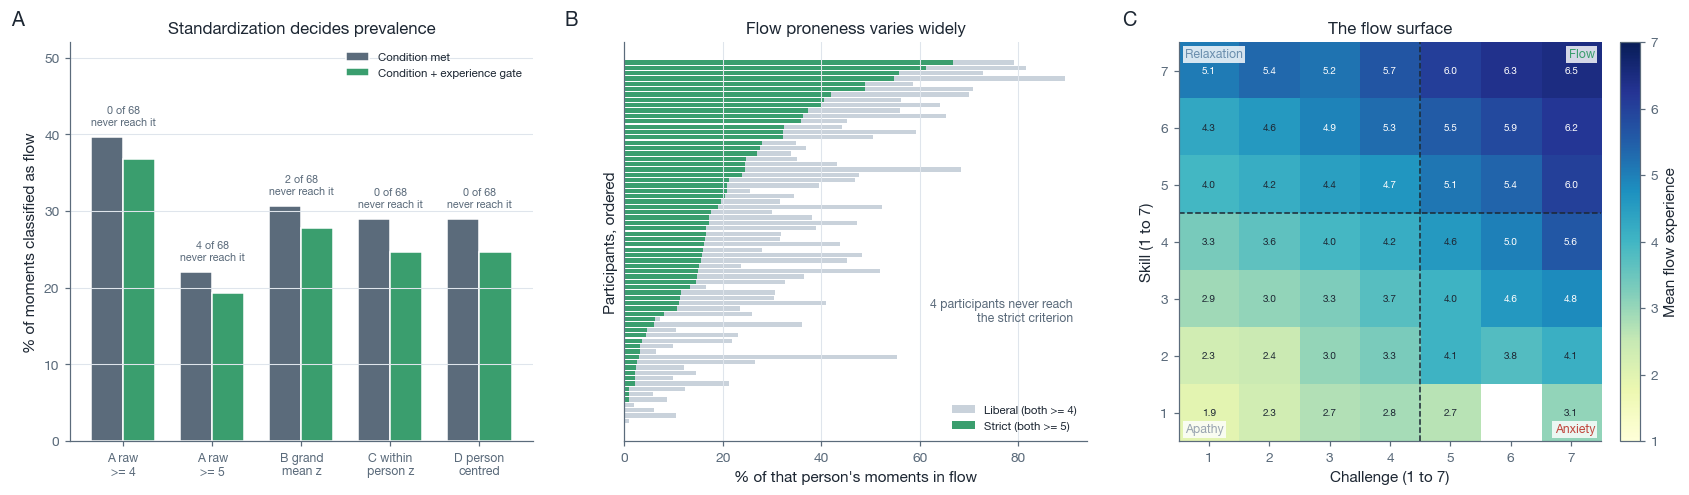

In [10]:
# Figure 2. Prevalence and the flow surface.
fig, ax = plt.subplots(1, 3, figsize=(15.4, 4.6))

a = ax[0]
order = ["A_abs4", "A_abs5", "B_grandz", "C_withinz", "D_center"]
short = {"A_abs4": "A raw\n>= 4", "A_abs5": "A raw\n>= 5", "B_grandz": "B grand\nmean z",
         "C_withinz": "C within\nperson z", "D_center": "D person\ncentred"}
pv = prev.set_index("rule").loc[order]
x = np.arange(len(order)); w = 0.36
cond_v = 100 * pv["moments_condition"].values
gate_v = 100 * pv["moments_gated"].values
a.bar(x - w / 2, cond_v, w, color=MUTED, edgecolor="white", label="Condition met")
a.bar(x + w / 2, gate_v, w, color=CHANNEL_COL["Flow"], edgecolor="white",
      label="Condition + experience gate")
for xi, nz, top in zip(x, pv["n_persons_zero"].values, np.maximum(cond_v, gate_v)):
    a.text(xi, top + 1.6, f"{int(nz)} of 68\nnever reach it", ha="center", fontsize=7,
           color=MUTED)
a.set_xticks(x); a.set_xticklabels([short[k] for k in order], fontsize=8)
a.set_ylim(0, 52); a.set_ylabel("% of moments classified as flow")
a.set_title("Standardization decides prevalence")
a.legend(fontsize=7.5); bar_axes(a); panel(a, "A")

a = ax[1]
pp = frame.groupby("pid")[["flow_gated_A_abs5", "flow_gated_A_abs4"]].mean()
pp = pp.sort_values("flow_gated_A_abs5")
y = np.arange(len(pp))
a.barh(y, 100 * pp["flow_gated_A_abs4"].values, color="#c9d2db", edgecolor="none",
       label="Liberal (both >= 4)")
a.barh(y, 100 * pp["flow_gated_A_abs5"].values, color=CHANNEL_COL["Flow"], edgecolor="none",
       label="Strict (both >= 5)")
a.set_yticks([]); a.set_ylabel("Participants, ordered")
a.set_xlabel("% of that person's moments in flow")
a.set_title("Flow proneness varies widely")
a.text(0.97, 0.30, f"{int((pp['flow_gated_A_abs5'] == 0).sum())} participants never reach\n"
       "the strict criterion", transform=a.transAxes, ha="right", fontsize=8, color=MUTED)
a.legend(fontsize=7.5, loc="lower right"); bar_axes(a, horizontal=True); panel(a, "B")

a = ax[2]
grid = np.full((7, 7), np.nan)
for (ch, sk), gr in frame.groupby(["CHALLENGE", "EFFIC"]):
    if len(gr) >= 10:
        grid[int(sk) - 1, int(ch) - 1] = gr["FLOWEXP"].mean()
im = a.imshow(grid, origin="lower", cmap="YlGnBu", vmin=1, vmax=7,
              extent=(0.5, 7.5, 0.5, 7.5), aspect="auto")
for si in range(7):
    for ci in range(7):
        if np.isfinite(grid[si, ci]):
            a.text(ci + 1, si + 1, f"{grid[si, ci]:.1f}", ha="center", va="center",
                   fontsize=6.5, color=INK if grid[si, ci] < 4.6 else "white")
a.axvline(4.5, color=INK, lw=1.0, ls="--"); a.axhline(4.5, color=INK, lw=1.0, ls="--")
box = {"facecolor": "white", "alpha": 0.82, "edgecolor": "none", "pad": 1.6}
for fx, fy, ha_, va_, name in [(0.985, 0.985, "right", "top", "Flow"),
                               (0.985, 0.015, "right", "bottom", "Anxiety"),
                               (0.015, 0.985, "left", "top", "Relaxation"),
                               (0.015, 0.015, "left", "bottom", "Apathy")]:
    a.text(fx, fy, name, transform=a.transAxes, fontsize=8, ha=ha_, va=va_,
           color=CHANNEL_COL[name], bbox=box, zorder=5,
           fontweight="bold" if name == "Flow" else "normal")
a.set_xticks(range(1, 8)); a.set_yticks(range(1, 8))
a.set_xlabel("Challenge (1 to 7)"); a.set_ylabel("Skill (1 to 7)")
a.set_title("The flow surface")
a.grid(False); fig.colorbar(im, ax=a, fraction=0.046, pad=0.04, label="Mean flow experience")
panel(a, "C")

fig.tight_layout(w_pad=2.6)
show(fig, "fig02_prevalence")

## Answer to V1

**Yes, and often, but the number depends entirely on the criterion, and that dependence is itself
the finding.**

Under the conservative absolute criterion (both condition items at 5 or above, plus a flow
experience of 5 or above), **19.3 percent of moments qualify as flow**, the median participant
reaches it in 16.4 percent of their moments, and **four of 68 participants never reach it at all**.
Under the liberal absolute criterion (both at 4 or above) the figure roughly doubles to 36.8
percent and nobody is at zero. Under the relative metrics, between 24.6 and 27.8 percent of moments
qualify and at most two participants are at zero.

Two substantive points beyond the headline number.

**The experience gate does real work, but it is not doing the heavy lifting.** Requiring the moment
to be experienced as absorbing and enjoyable, and not merely structurally balanced, removes 2.7 to
4.4 percentage points, roughly one in eight candidate moments. Worth keeping as the conceptual
safeguard against "balanced but disengaged".

**The sample sits in the relaxation corner, not the flow corner.** Under the strict rule the
largest channel is relaxation (37.0 percent, low challenge and high skill), not flow (22.0 percent
before gating). Panel C shows why: the modal moment has low challenge and moderate to high skill.
This population spends most of its diary time doing familiar, undemanding things it is good at.
That is a clinically sensible picture of daily life with chronic pain, and it shapes everything
that follows.

Note also the activation column in the channel profile: flow moments average 4.33 on physical
activation against 2.47 in relaxation. Challenge, in this dataset, means being physically active.
Section 8 returns to what that costs.

---
# 6. V2, the model

> **V2. Relational, the model itself.** Does the flow model behave as expected, that is, does the
> challenge-skill configuration predict the flow experience (absorption and enjoyment)? This
> requires within-person variation, so multilevel or idiographic estimation.

**Method the question dictates.** Metric D, condition option 2 (balance and elevation), analysis
track B (hybrid multilevel with random slopes). Track B is chosen over track A (random intercepts
only) because a fixed average would mask exactly the person heterogeneity this project cares about,
and over track C (fully per person) because partial pooling stabilises the shorter series while
still quantifying the spread.

**Specification.**

```
FLOWEXP ~ balance_w + elevation_w + balance_b + elevation_b + (1 + balance_w + elevation_w | pid)
```

The within terms carry the momentary flow model. The between terms absorb stable person differences
in challenge and skill so the within estimates are not contaminated by them: the standard
within-between decomposition.

**Produced by** `01_flow_construct.R`, section 4.

In [11]:
fixed = T("condition_experience_fixed")
rand = T("condition_experience_random")

TERMS = {"balance_w": "Balance (within)", "elevation_w": "Elevation (within)",
         "balance_b": "Balance (between)", "elevation_b": "Elevation (between)"}
v2 = fixed[(fixed["model"] == "balance + elevation") & fixed["term"].isin(TERMS)].copy()
rsd = rand[rand["model"] == "balance + elevation"].set_index("term")["random_SD"]
v2["term"] = v2["term"].map(TERMS)
v2["random SD"] = [rsd.get(t, "") for t in
                   fixed[(fixed["model"] == "balance + elevation") &
                         fixed["term"].isin(TERMS)]["term"]]
v2["p"] = v2["p"].map(fmt_p)
v2 = v2[["term", "estimate", "SE", "df", "t", "p", "random SD"]]
display(v2)

,term,estimate,SE,df,t,p,random SD
1,Balance (within),0.006,0.020,71.6,0.28,.782,0.131
2,Elevation (within),0.744,0.024,63.9,31.63,<.001,0.164
3,Balance (between),-0.111,0.049,64.3,-2.24,.028,
4,Elevation (between),0.796,0.085,61.3,9.33,<.001,


### Alternative parameterizations

Before interpreting, the primary specification is compared against the two obvious alternatives:
the additive form with an interaction (challenge and skill as separate main effects plus their
product) and the categorical quadrant. If a different form fits better, that is substantive
information about how the condition actually works.

In [12]:
alt = fixed[fixed["model"].isin(["challenge x skill", "quadrant (vs apathy)"])].copy()
alt = alt[alt["term"] != "(Intercept)"]
alt["p"] = alt["p"].map(fmt_p)
display(alt[["model", "term", "estimate", "SE", "t", "p"]])

cmp = T("condition_model_comparison").sort_values("AIC").reset_index(drop=True)
cmp["AIC difference"] = (cmp["AIC"] - cmp["AIC"].min()).round(1)
display(cmp[["model", "AIC", "BIC", "AIC difference", "n_obs"]])

,model,term,estimate,SE,t,p
6,challenge x skill,CHALLENGE_w,0.296,0.018,16.13,<.001
7,challenge x skill,EFFIC_w,0.486,0.020,24.24,<.001
8,challenge x skill,CHALLENGE_b,0.332,0.056,5.89,<.001
9,challenge x skill,EFFIC_b,0.484,0.075,6.47,<.001
10,challenge x skill,CHALLENGE_w:EFFIC_w,-0.007,0.005,-1.43,.152
12,quadrant (vs apathy),chan_DFlow,2.118,0.040,53.12,<.001
13,quadrant (vs apathy),chan_DRelaxation,1.255,0.041,30.58,<.001
14,quadrant (vs apathy),chan_DAnxiety,0.951,0.045,20.99,<.001


,model,AIC,BIC,AIC difference,n_obs
0,challenge x skill,16879.7,16966.7,0.0,5976
1,balance + elevation,17320.8,17401.1,441.1,5976
2,quadrant (vs apathy),18482.0,18522.2,1602.3,5976


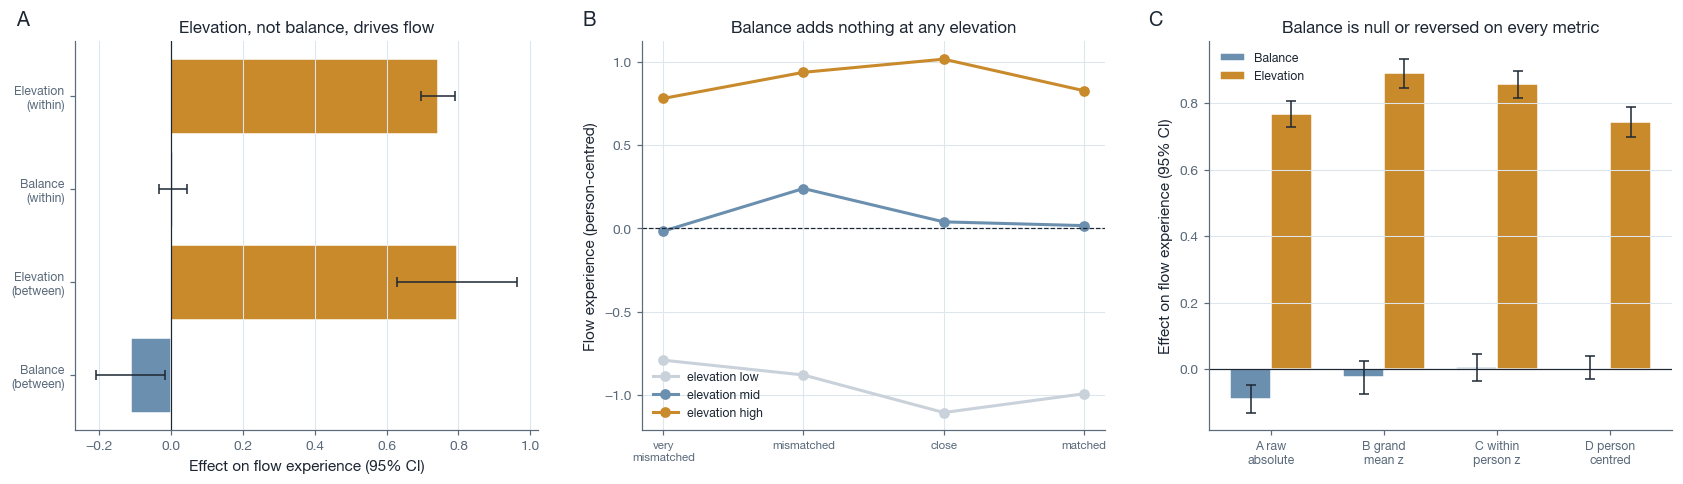

In [13]:
# Figure 3. The condition-to-experience model.
fig, ax = plt.subplots(1, 3, figsize=(15.4, 4.5))

a = ax[0]
src = fixed[fixed["model"] == "balance + elevation"].set_index("term")
terms = ["elevation_w", "balance_w", "elevation_b", "balance_b"]
labs = ["Elevation\n(within)", "Balance\n(within)", "Elevation\n(between)", "Balance\n(between)"]
vals = [src.loc[t, "estimate"] for t in terms]
ses = [src.loc[t, "SE"] for t in terms]
cols = [COL["elevation"], COL["balance"]] * 2
y = np.arange(len(terms))[::-1]
a.barh(y, vals, xerr=1.96 * np.array(ses), color=cols, edgecolor="white",
       error_kw={"ecolor": INK, "elinewidth": 1.0, "capsize": 3})
a.axvline(0, color=INK, lw=0.8)
a.set_yticks(y); a.set_yticklabels(labs, fontsize=8)
a.set_xlabel("Effect on flow experience (95% CI)")
a.set_title("Elevation, not balance, drives flow")
bar_axes(a, horizontal=True); panel(a, "A")

a = ax[1]
d3 = frame.dropna(subset=["balance_w", "elevation_w", "FLOWEXP_w"]).copy()
d3["elev_bin"] = pd.qcut(d3["elevation_w"], 3, labels=["low", "mid", "high"])
d3["bal_bin"] = pd.cut(d3["balance_w"], bins=[-6.5, -2.5, -1.5, -0.5, 0.5],
                       labels=["very\nmismatched", "mismatched", "close", "matched"])
for lab_e, colr in zip(["low", "mid", "high"], ["#c9d2db", COL["balance"], COL["elevation"]]):
    sub = d3[d3["elev_bin"] == lab_e].groupby("bal_bin", observed=True)["FLOWEXP_w"].mean()
    a.plot(range(len(sub)), sub.values, "o-", color=colr, lw=2, ms=6,
           label=f"elevation {lab_e}")
a.set_xticks(range(4))
a.set_xticklabels(["very\nmismatched", "mismatched", "close", "matched"], fontsize=7.5)
a.axhline(0, color=INK, lw=0.8, ls="--")
a.set_ylabel("Flow experience (person-centred)")
a.set_title("Balance adds nothing at any elevation")
a.legend(fontsize=8); panel(a, "B")

a = ax[2]
sens = T("standardization_sensitivity")
morder = ["A_raw", "B_grandz", "C_withinz", "D_center"]
mlab = {"A_raw": "A raw\nabsolute", "B_grandz": "B grand\nmean z",
        "C_withinz": "C within\nperson z", "D_center": "D person\ncentred"}
x = np.arange(len(morder)); w = 0.36
for k, (term, colr) in enumerate([("Balance", COL["balance"]),
                                  ("Elevation", COL["elevation"])]):
    sub = sens[sens["term"] == term].set_index("metric").loc[morder]
    a.bar(x + (k - 0.5) * w, sub["estimate"], w, yerr=1.96 * sub["SE"], color=colr,
          label=term, edgecolor="white",
          error_kw={"ecolor": INK, "elinewidth": 1.0, "capsize": 3})
a.axhline(0, color=INK, lw=0.8)
a.set_xticks(x); a.set_xticklabels([mlab[m] for m in morder], fontsize=8)
a.set_ylabel("Effect on flow experience (95% CI)")
a.set_title("Balance is null or reversed on every metric")
a.legend(fontsize=8, loc="upper left"); bar_axes(a); panel(a, "C")

fig.tight_layout(w_pad=2.8)
show(fig, "fig03_condition_experience")

## Answer to V2

**The flow model holds in one half and fails in the other, and the failure is not a null but a
reversal.**

**What works.** Elevation is a very strong predictor of the flow experience within persons
(b = 0.744, SE = 0.024, p < .001). A moment in which challenge and skill are both above the
person's own average is substantially more absorbing and enjoyable. There is real heterogeneity in
that slope across persons (random SD = 0.164, against a fixed effect of 0.744).

**What fails.** Within-person balance is exactly null (b = 0.006, SE = 0.020, p = .78). Panel B
shows why this is not a power problem: at every level of elevation the flow experience is flat
across the whole range from very mismatched to perfectly matched. The three lines are separated by
elevation and are individually horizontal. Between persons the balance effect is significantly
**negative** (b = -0.111, SE = 0.049, p = .028), and panel C shows the same reversal on the raw
absolute scale (b = -0.090, p < .001).

**How to read the between-person reversal.** People whose challenge and skill ratings are on
average better matched report a *lower* average flow experience. The most plausible reading in this
population: chronically matched challenge and skill indexes a narrow, low-demand activity
repertoire, someone who only ever does the easy things they are good at, rather than a person
living in the optimal-challenge zone. This is a between-person description of an activity pattern,
not a within-person mechanism, and should be presented as such.

**Which parameterization the data prefer.** The additive form, challenge and skill as separate main
effects, fits substantially better than the balance-and-elevation form (AIC 16880 against 17321, a
difference of 441), and the challenge-by-skill interaction inside it is not significant
(b = -0.007, p = .15). Skill carries about 1.6 times the weight of challenge (0.486 against 0.296).
The categorical quadrant fits worst by a wide margin (a further 1163 AIC points), which is the
expected cost of throwing away continuous information.

**The methodological conclusion.** In this dataset the flow condition acts **additively**, not
configurationally. More challenge helps, more skill helps more, and their matching is irrelevant.
That is a genuine, reportable, partly negative result about the flow model, consistent in direction
with the meta-analytic finding that the pure balance effect is weak once elevation is accounted for
(Fong et al., 2015) and stronger than it.

---
# 7. V3, dynamics

> **V3. Idiographic dynamics.** Does the flow relation differ per person, and is there temporal
> structure, that is, does the challenge-skill configuration precede absorption in time? This
> requires per-person models.

**Method the question dictates.** Lags built within day, on person-standardized scores, so no lag
crosses the overnight gap and the coefficients sit on the same metric as the study's other lagged
analyses. Roughly 90 minutes separate consecutive beeps. Two levels: a multilevel lagged model for
the average temporal effect, and per-person regressions for the distribution.

**Produced by** `02_flow_pain_models.R`, sections 2b and 3.

## 7.1 Does the condition at t-1 predict the experience at t?

In [14]:
v3 = T("condition_lagged")
v3 = v3[v3["term"] != "(Intercept)"].copy()
v3["p"] = v3["p"].map(fmt_p)
NICE = {"balance_zz_lag": "Balance (t-1)", "elevation_zz_lag": "Elevation (t-1)",
        "FLOWEXP_lag": "Flow experience (t-1), autoregression",
        "balance_zz": "Balance (same beep)", "elevation_zz": "Elevation (same beep)"}
v3["term"] = v3["term"].map(NICE)
display(v3[["model", "term", "estimate", "SE", "t", "p", "n_obs"]])

lag_e = float(v3.loc[v3["term"] == "Elevation (t-1)", "estimate"].iloc[0])
same_e = float(v3.loc[v3["term"] == "Elevation (same beep)", "estimate"].iloc[0])
print(f"\nlagged elevation is {100 * lag_e / same_e:.0f}% of the concurrent elevation effect")

,model,term,estimate,SE,t,p,n_obs
1,condition(t-1) -> experience(t),Balance (t-1),-0.007,0.017,-0.39,.696,5065
2,condition(t-1) -> experience(t),Elevation (t-1),0.052,0.028,1.88,.062,5065
3,condition(t-1) -> experience(t),"Flow experience (t-1), autoregression",0.108,0.019,5.80,<.001,5065
5,"condition(t) -> experience(t), same rows",Balance (same beep),-0.001,0.022,-0.05,.963,5065
6,"condition(t) -> experience(t), same rows",Elevation (same beep),0.856,0.022,39.74,<.001,5065



lagged elevation is 6% of the concurrent elevation effect


**Reading.** There is at most a faint temporal signature inside the flow model. Elevation at the
previous beep predicts the flow experience at the current beep with b = 0.052 (SE = 0.028), which
is **marginal and not significant** (p = .062), over and above the flow experience's own
autoregression (b = 0.108, p < .001). Balance at t-1 does nothing (b = -0.007, p = .70), consistent
with its concurrent null.

The size is the point. The lagged elevation effect is about **6 percent** of the concurrent one
(0.052 against 0.856). A demanding, masterful moment may leave a faint absorption residue roughly
90 minutes later, but the flow model is overwhelmingly a same-moment phenomenon. The temporal
antecedence the theory implies is, at this sampling interval, not detectable.

## 7.2 Does the flow-pain relation differ per person?

In [15]:
per = T("perperson_slopes")
summ = T("perperson_summary")
summ = summ[summ["quantity"].isin(["contemporaneous b", "lagged b"])].copy()
summ["quantity"] = summ["quantity"].str.replace(" b", " slope")
summ["IQR"] = summ["q25"].round(3).astype(str) + " to " + summ["q75"].round(3).astype(str)
summ["range"] = summ["min"].round(3).astype(str) + " to " + summ["max"].round(3).astype(str)
display(summ[["quantity", "n_persons", "median", "IQR", "range", "pct_negative",
              "n_sig_negative", "n_sig_positive"]])

,quantity,n_persons,median,IQR,range,pct_negative,n_sig_negative,n_sig_positive
1,contemporaneous slope,63,-0.137,-0.203 to 0.01,-0.465 to 0.445,73.0,14.0,4.0
2,lagged slope,63,0.000,-0.084 to 0.052,-0.265 to 0.227,49.2,2.0,0.0


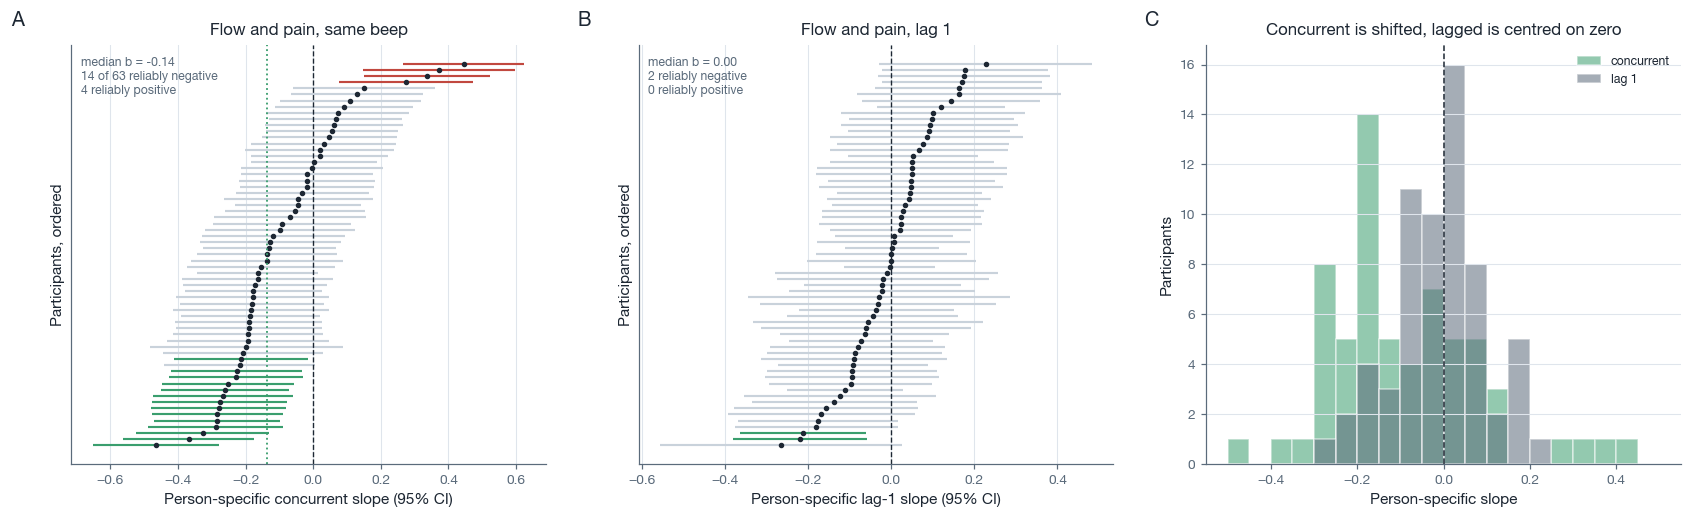

In [16]:
# Figure 4. Person specificity.
fig, ax = plt.subplots(1, 3, figsize=(15.4, 4.8))

a = ax[0]
pp = per.dropna(subset=["b_contemp"]).sort_values("b_contemp").reset_index(drop=True)
y = np.arange(len(pp))
sig_neg, sig_pos = pp["hi_contemp"] < 0, pp["lo_contemp"] > 0
cols = np.where(sig_neg, CHANNEL_COL["Flow"], np.where(sig_pos, COL["PIJN"], "#c9d2db"))
a.hlines(y, pp["lo_contemp"], pp["hi_contemp"], color=cols, lw=1.4)
a.plot(pp["b_contemp"], y, "o", ms=2.6, color=INK)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.axvline(pp["b_contemp"].median(), color=CHANNEL_COL["Flow"], lw=1.2, ls=":")
a.text(0.02, 0.97, f"median b = {pp['b_contemp'].median():.2f}\n"
       f"{int(sig_neg.sum())} of {len(pp)} reliably negative\n"
       f"{int(sig_pos.sum())} reliably positive",
       transform=a.transAxes, va="top", fontsize=8, color=MUTED)
a.set_yticks([]); a.set_ylabel("Participants, ordered")
a.set_xlabel("Person-specific concurrent slope (95% CI)")
a.set_title("Flow and pain, same beep")
panel(a, "A")

a = ax[1]
pl = per.dropna(subset=["b_lagged"]).sort_values("b_lagged").reset_index(drop=True)
y = np.arange(len(pl))
sn, sp = pl["hi_lagged"] < 0, pl["lo_lagged"] > 0
cols = np.where(sn, CHANNEL_COL["Flow"], np.where(sp, COL["PIJN"], "#c9d2db"))
a.hlines(y, pl["lo_lagged"], pl["hi_lagged"], color=cols, lw=1.4)
a.plot(pl["b_lagged"], y, "o", ms=2.6, color=INK)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.text(0.02, 0.97, f"median b = {pl['b_lagged'].median():.2f}\n"
       f"{int(sn.sum())} reliably negative\n{int(sp.sum())} reliably positive",
       transform=a.transAxes, va="top", fontsize=8, color=MUTED)
a.set_yticks([]); a.set_ylabel("Participants, ordered")
a.set_xlabel("Person-specific lag-1 slope (95% CI)")
a.set_title("Flow and pain, lag 1")
panel(a, "B")

a = ax[2]
bins = np.linspace(-0.5, 0.5, 21)
a.hist(pp["b_contemp"], bins=bins, color=CHANNEL_COL["Flow"], alpha=0.55,
       edgecolor="white", label="concurrent")
a.hist(pl["b_lagged"], bins=bins, color=MUTED, alpha=0.55, edgecolor="white", label="lag 1")
a.axvline(0, color=INK, lw=1.0, ls="--")
a.set_xlabel("Person-specific slope"); a.set_ylabel("Participants")
a.set_title("Concurrent is shifted, lagged is centred on zero")
a.legend(fontsize=8); bar_axes(a); panel(a, "C")

fig.tight_layout(w_pad=2.6)
show(fig, "fig04_person_specificity")

## Answer to V3

**Temporal structure: essentially absent.** Inside the flow model the lagged condition effect is
marginal and about 6 percent of the concurrent one. Between flow and pain there is nothing at lag 1
in either direction (section 8).

**Person specificity: substantial, and the most clinically interesting result here.**

The concurrent flow-pain slope has a median of -0.137, an interquartile range from -0.203 to
+0.010, and a range from -0.465 to +0.445. **73 percent of participants show the negative pattern**,
14 of 63 with a confidence interval entirely below zero, and **4 with a confidence interval
entirely above zero**. For those four, more absorption reliably accompanies more pain.

The lagged distribution is a striking contrast. Its median is 0.000, 49.2 percent of persons are
negative, and only 2 of 63 reach reliability in either direction, which is roughly what one expects
by chance at 5 percent. Panel C makes the comparison unambiguous: the concurrent distribution is
displaced to the left of zero, the lagged distribution sits on top of it.

**Interpretation.** Activity engagement is a defensible default target in daily-life pain
management, but not a universal one, and which kind of person someone is can be established from a
two-week diary. That is a concrete, checkable, individual-level claim, and it reinforces the
idiographic argument the wider study makes.

---
# 8. Flow and the momentary experience of pain

This section goes beyond the operationalization question. Its motivation is theoretical: the
interruptive-function model (Eccleston and Crombez, 1999) holds that pain captures attention away
from goal pursuit, while flow describes the state in which goal pursuit absorbs attention so
completely that competing signals fail to intrude. Flow is, in that sense, the mirror image of pain
interruption. A recent review (Gromakovskis and Gutmanis, 2025) proposes "flow-induced analgesia"
as a mechanism and notes explicitly that it has never been examined in daily life.

Four outcomes, each in an unadjusted and an activity-adjusted version, because challenge co-occurs
strongly with being physically active (within-person r = .57) and activity independently raises
pain in this population.

**Produced by** `02_flow_pain_models.R`, sections 1 and 2.

## 8.1 Same beep

In [17]:
con = T("pain_contemporaneous")
foc = con[con["term"] == "FLOWEXP_w"].copy()
foc["outcome"] = foc["outcome"].map(LABEL)
foc["p"] = foc["p"].map(fmt_p)
display(foc[["outcome", "model", "estimate", "SE", "df", "t", "p", "n_obs"]]
        .sort_values(["outcome", "model"]).reset_index(drop=True))

rs = T("pain_random_slopes").copy()
rs["outcome"] = rs["outcome"].map(LABEL)
rs.columns = ["outcome", "random SD (unadjusted)", "random SD (activity-adjusted)"]
print("\nHeterogeneity of the flow effect across persons:")
display(rs)

,outcome,model,estimate,SE,df,t,p,n_obs
0,Attention to pain,activity-adjusted,-0.074,0.019,88.7,-3.95,<.001,5941
1,Attention to pain,base,-0.077,0.019,88.1,-4.13,<.001,5948
2,Pain intensity,activity-adjusted,-0.094,0.020,106.1,-4.69,<.001,5969
3,Pain intensity,base,-0.096,0.020,105.7,-4.83,<.001,5976
4,Pain interference,activity-adjusted,-0.139,0.025,89.5,-5.56,<.001,5931
5,Pain interference,base,-0.143,0.025,88.8,-5.78,<.001,5938
6,Threat value,activity-adjusted,-0.079,0.014,95.5,-5.70,<.001,5947
7,Threat value,base,-0.080,0.014,94.1,-5.82,<.001,5954



Heterogeneity of the flow effect across persons:


,outcome,random SD (unadjusted),random SD (activity-adjusted)
0,Pain intensity,0.113,0.114
1,Attention to pain,0.096,0.097
2,Pain interference,0.143,0.146
3,Threat value,0.070,0.071


In [18]:
# The full activity-adjusted pain model: is anything left for the condition terms?
full = con[(con["model"] == "activity-adjusted") & (con["outcome"] == "PIJN") &
           (con["term"] != "(Intercept)")].copy()
full["term"] = full["term"].map({"FLOWEXP_w": "Flow experience", "balance_w": "Balance",
                                 "elevation_w": "Elevation", "ACTIEF_w": "Physical activation"})
full["p"] = full["p"].map(fmt_p)
display(full[["term", "estimate", "SE", "t", "p"]])

,term,estimate,SE,t,p
5,Flow experience,-0.094,0.020,-4.69,<.001
6,Balance,-0.025,0.012,-2.03,.043
7,Elevation,-0.003,0.018,-0.14,.885
8,Physical activation,0.019,0.010,1.98,.048


## 8.2 Lag 1, both directions

In [19]:
lag = T("pain_lagged")
fw = lag[(lag["model"] == "flow(t-1) -> outcome(t)") & (lag["term"] == "FLOWEXP_lag")].copy()
fw["label"] = "Flow -> " + fw["outcome"].map(LABEL)
rv = lag[lag["model"] == "predictor(t-1) -> flow(t)"].copy()
rv = rv[rv["term"] == rv["outcome"] + "_lag"]
rv["label"] = rv["outcome"].map(LABEL) + " -> Flow"
lagged = pd.concat([fw, rv], ignore_index=True)
lagged["p"] = lagged["p"].map(fmt_p)
display(lagged[["label", "estimate", "SE", "t", "p", "n_obs"]])

# autoregressions, to show the lagged models are working
ar = lag[lag["term"].str.endswith("_lag") & (lag["term"] != "FLOWEXP_lag") &
         (lag["model"] == "flow(t-1) -> outcome(t)")].copy()
ar["term"] = ar["outcome"].map(LABEL) + " (t-1)"
ar["p"] = ar["p"].map(fmt_p)
print("\nAutoregressions in the same models:")
display(ar[["term", "estimate", "SE", "p"]])

,label,estimate,SE,t,p,n_obs
0,Flow -> Pain intensity,-0.002,0.014,-0.14,.888,5065
1,Flow -> Attention to pain,-0.012,0.016,-0.76,.451,5016
2,Flow -> Pain interference,0.001,0.014,0.10,.921,4999
3,Flow -> Threat value,-0.011,0.014,-0.78,.439,5025
4,Pain intensity -> Flow,-0.019,0.018,-1.09,.280,5065
5,Attention to pain -> Flow,-0.001,0.016,-0.08,.937,5039
6,Threat value -> Flow,-0.017,0.018,-0.96,.342,5044



Autoregressions in the same models:


,term,estimate,SE,p
2,Pain intensity (t-1),0.395,0.013,<.001
5,Attention to pain (t-1),0.266,0.013,<.001
8,Pain interference (t-1),0.352,0.013,<.001
11,Threat value (t-1),0.321,0.013,<.001


## 8.3 Which channel is least painful?

In [20]:
chan = T("channel_contrasts")
chan = chan[chan["term"].str.startswith("chan")].copy()
chan["channel"] = chan["term"].str.replace("chan", "", regex=False)
chan["outcome"] = chan["outcome"].map(LABEL)
chan["p"] = chan["p"].map(fmt_p)
display(chan.pivot(index="channel", columns="outcome", values="estimate")
        .reindex(["Flow", "Relaxation", "Anxiety"])[[LABEL[o] for o in OUTCOMES]])
display(chan[["outcome", "channel", "estimate", "SE", "t", "p"]].reset_index(drop=True))

outcome,Pain intensity,Pain interference,Attention to pain,Threat value
channel,,,,
Flow,-0.179,-0.173,-0.169,-0.070
Relaxation,-0.210,-0.272,-0.280,-0.167
Anxiety,0.028,0.131,-0.006,0.043


,outcome,channel,estimate,SE,t,p
0,Pain intensity,Flow,-0.179,0.039,-4.58,<.001
1,Pain intensity,Relaxation,-0.210,0.040,-5.24,<.001
2,Pain intensity,Anxiety,0.028,0.044,0.64,.522
3,Attention to pain,Flow,-0.169,0.039,-4.31,<.001
4,Attention to pain,Relaxation,-0.280,0.040,-6.96,<.001
5,Attention to pain,Anxiety,-0.006,0.044,-0.14,.888
6,Pain interference,Flow,-0.173,0.047,-3.65,<.001
7,Pain interference,Relaxation,-0.272,0.049,-5.56,<.001
8,Pain interference,Anxiety,0.131,0.054,2.44,.015
9,Threat value,Flow,-0.070,0.030,-2.36,.018


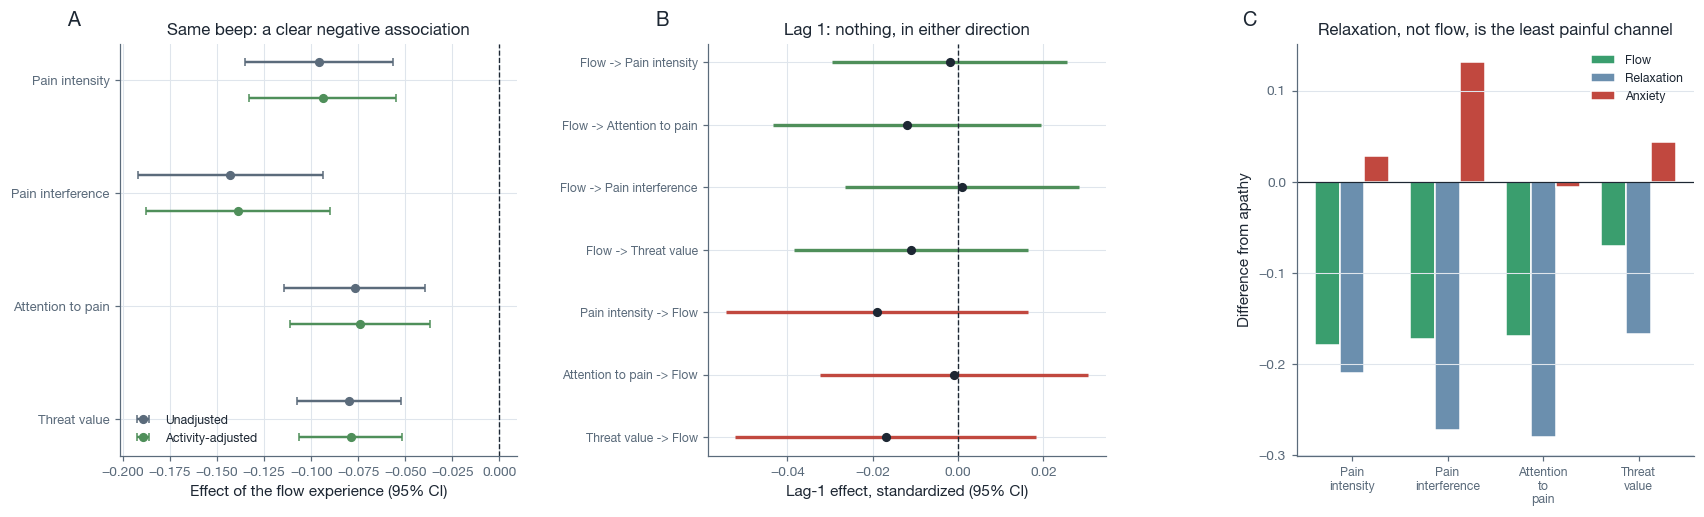

In [21]:
# Figure 5. Flow and pain.
fig, ax = plt.subplots(1, 3, figsize=(15.6, 4.8))

a = ax[0]
y = np.arange(len(OUTCOMES))[::-1]
for shift, mdl, colr, lab in [(0.16, "base", MUTED, "Unadjusted"),
                              (-0.16, "activity-adjusted", COL["FLOWEXP"],
                               "Activity-adjusted")]:
    sub = con[(con["model"] == mdl) & (con["term"] == "FLOWEXP_w")].set_index("outcome")
    est = np.array([sub.loc[o, "estimate"] for o in OUTCOMES])
    se = np.array([sub.loc[o, "SE"] for o in OUTCOMES])
    a.errorbar(est, y + shift, xerr=1.96 * se, fmt="o", ms=5, color=colr, ecolor=colr,
               elinewidth=1.6, capsize=2.5, label=lab)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.set_yticks(y); a.set_yticklabels([LABEL[o] for o in OUTCOMES], fontsize=8.5)
a.set_xlabel("Effect of the flow experience (95% CI)")
a.set_title("Same beep: a clear negative association")
a.legend(fontsize=8, loc="lower left"); panel(a, "A")

a = ax[1]
y = np.arange(len(lagged))[::-1]
cols = [COL["FLOWEXP"] if l.startswith("Flow ->") else COL["PIJN"] for l in lagged["label"]]
for yy, e, s, c in zip(y, lagged["estimate"], lagged["SE"], cols):
    a.hlines(yy, e - 1.96 * s, e + 1.96 * s, color=c, lw=2.2)
    a.plot(e, yy, "o", ms=5, color=INK, zorder=3)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.set_yticks(y); a.set_yticklabels(lagged["label"], fontsize=8)
a.set_xlabel("Lag-1 effect, standardized (95% CI)")
a.set_title("Lag 1: nothing, in either direction")
panel(a, "B")

a = ax[2]
piv = chan.pivot(index="channel", columns="outcome", values="estimate")
piv = piv.reindex(["Flow", "Relaxation", "Anxiety"])[[LABEL[o] for o in OUTCOMES]]
x = np.arange(len(OUTCOMES)); w = 0.26
for k, ch_name in enumerate(piv.index):
    a.bar(x + (k - 1) * w, piv.loc[ch_name].values, w, color=CHANNEL_COL[ch_name],
          edgecolor="white", label=ch_name)
a.axhline(0, color=INK, lw=0.8)
a.set_xticks(x)
a.set_xticklabels([LABEL[o].replace(" ", "\n") for o in OUTCOMES], fontsize=8)
a.set_ylabel("Difference from apathy")
a.set_title("Relaxation, not flow, is the least painful channel")
a.legend(fontsize=8); bar_axes(a); panel(a, "C")

fig.tight_layout(w_pad=2.8)
show(fig, "fig05_flow_and_pain")

## What section 8 shows

**A significant concurrent association on all four outcomes, surviving every adjustment.** Within
persons, a higher than usual flow experience goes with lower pain intensity (b = -0.094,
SE = 0.020, p < .001), lower pain interference (b = -0.139, SE = 0.025, p < .001), less attention to
pain (b = -0.074, SE = 0.019, p < .001), and lower threat value (b = -0.079, SE = 0.014, p < .001).
Adjusting for physical activation leaves every estimate essentially unchanged, so the
challenge-activity confound, the most obvious threat to this analysis, does not bite.

**The effect runs through the experience, not the condition.** In the full pain model the flow
experience is the only clearly significant predictor. Elevation and balance add nothing once it is
included. That is exactly the pattern an attentional mechanism predicts: what matters is being
absorbed, not the structural properties of the activity.

**The effect is largest where the theory says it should be.** Pain interference (-0.139) is the
most strongly related outcome, pain intensity (-0.094) intermediate, attention (-0.074) and threat
(-0.079) smaller. Flow modulates how much pain disrupts more than how intense it feels. That is
precisely the prediction of the interruptive-function model and is arguably a cleaner theoretical
result than a raw intensity effect would have been.

**Size and heterogeneity.** These are small effects. On the raw 1 to 7 scale, a one-point increase
in the flow experience corresponds to roughly a tenth of a point less pain. The random slope
standard deviations (0.070 to 0.146) are as large as the fixed effects themselves, so the
between-person spread is comparable to the average effect. Pain interference has both the largest
average effect and the largest spread.

**Nothing at lag 1, in either direction.** Flow at the previous beep does not predict pain,
interference, attention, or threat. Pain, attention, and threat at the previous beep do not predict
flow. Meanwhile every autoregression is large and highly significant (pain 0.395, interference
0.352, threat 0.321, attention 0.266), which establishes that the lagged models are working and
simply find nothing. **The relation is strictly concurrent, and no causal or temporal claim is
available from these data.**

**Relaxation outperforms flow.** Against apathy as the reference, flow moments carry less pain
(-0.179), less interference (-0.173), less attention (-0.169), and less threat (-0.070), all
p < .05. But relaxation moments, low challenge with high skill, are better on every single one
(-0.210, -0.272, -0.280, -0.167). Anxiety moments, high challenge with low skill, are no better
than apathy and significantly *worse* on interference (+0.131, p = .015).

This is the most substantively interesting result the analysis produces, and it complicates the
flow story rather than confirming it. In chronic pain the protective ingredient looks like
**competence without demand**, not the optimal-challenge state that flow theory privileges. The
raw-scale profile in section 5 points the same way: under the strict absolute rule, flow moments
carry the *highest* mean pain of any channel (4.90), because high challenge co-occurs with physical
activity (mean activation 4.33 in flow against 2.47 in relaxation) and activity costs pain in this
population.

The synthesis: the flow *experience* is protective, but the challenge half of the flow *condition*
carries a physical cost that partly offsets it. A review of induced-flow interventions such as
virtual reality or music could not have anticipated this, because those paradigms supply the
challenge without the physical exertion.

---
# 9. Flow proneness and baseline trait profiles

Flow is a momentary state, but the *propensity* to reach it is a person-level quantity, and that is
the only level at which flow can legitimately meet a trait framework. Three person-level flow
variables are related to the three baseline accounts already used in the study: a threat account
(catastrophizing plus pain vigilance), a biomedical account (pain severity and duration), and a
personality account (neuroticism).

With 68 participants this is exploratory and powered only for moderate effects.

**Produced by** `03_flow_trait_link.py`.

In [22]:
link = T("trait_link")
link["zero_order_p"] = link["zero_order_p"].map(fmt_p)
link["partial_p"] = link["partial_p"].map(fmt_p)
link.columns = ["flow variable", "account", "n", "r", "p",
                "partial r (control mean pain)", "partial p"]
display(link)

,flow variable,account,n,r,p,partial r (control mean pain),partial p
0,Flow proneness (strict),Threat,67,-0.092,.459,-0.146,.238
1,Flow proneness (strict),Biomedical,67,0.294,.016,0.048,.702
2,Flow proneness (strict),Personality,64,0.045,.722,-0.097,.444
3,Mean flow experience,Threat,67,-0.268,.028,-0.274,.025
4,Mean flow experience,Biomedical,67,0.032,.798,0.003,.982
5,Mean flow experience,Personality,64,-0.264,.035,-0.285,.022
6,Mean challenge,Threat,67,-0.047,.707,-0.096,.440
7,Mean challenge,Biomedical,67,0.166,.178,-0.131,.290
8,Mean challenge,Personality,64,0.157,.216,0.030,.812
9,Mean skill,Threat,67,-0.114,.360,-0.117,.344


In [23]:
inc = T("incremental_r2")
inc.columns = ["outcome", "flow variable added", "n", "R2 accounts",
               "R2 accounts + flow", "delta R2"]
display(inc)
print("Note. Mean absorption is deliberately excluded as an outcome: it is one of the two items\n"
      "inside the flow experience, so regressing it on flow proneness would be circular.")

,outcome,flow variable added,n,R2 accounts,R2 accounts + flow,delta R2
0,Attention to pain,Flow proneness (strict),64,0.196,0.229,0.033
1,Attention to pain,Mean flow experience,64,0.196,0.208,0.012
2,Pain intensity,Flow proneness (strict),64,0.362,0.443,0.081
3,Pain intensity,Mean flow experience,64,0.362,0.363,0.001
4,Pain interference,Flow proneness (strict),64,0.355,0.388,0.033
5,Pain interference,Mean flow experience,64,0.355,0.359,0.004
6,Threat value,Flow proneness (strict),64,0.408,0.417,0.009
7,Threat value,Mean flow experience,64,0.408,0.422,0.014


Note. Mean absorption is deliberately excluded as an outcome: it is one of the two items
inside the flow experience, so regressing it on flow proneness would be circular.


In [24]:
grp = T("coupling_groups")
grp["p"] = grp["p"].map(fmt_p)
grp.columns = ["variable", "n negative couplers", "n others", "mean (negative)",
               "mean (others)", "Cohen d", "p"]
display(grp)

,variable,n negative couplers,n others,mean (negative),mean (others),Cohen d,p
0,Threat,45,17,0.059,-0.271,0.398,.151
1,Biomedical,45,17,-0.071,0.272,-0.460,.131
2,Personality,42,17,-0.002,-0.133,0.129,.654
3,Flow proneness (strict),45,17,0.161,0.293,-0.739,.027
4,Mean pain,45,17,4.313,5.073,-0.690,.029


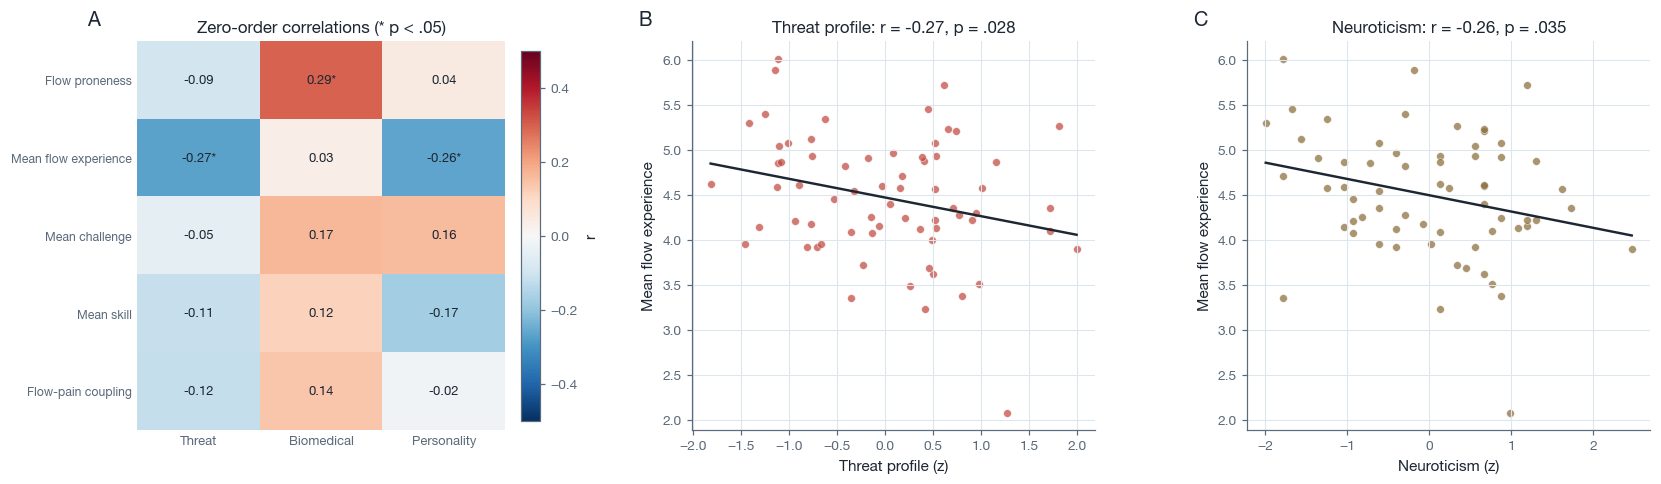

In [25]:
# Figure 6. Person-level flow and baseline profiles.
link_raw = T("trait_link")
fig, ax = plt.subplots(1, 3, figsize=(15.2, 4.5))

a = ax[0]
fv_order = ["Flow proneness (strict)", "Mean flow experience", "Mean challenge",
            "Mean skill", "Flow-pain coupling"]
acc_order = ["Threat", "Biomedical", "Personality"]
M = np.full((len(fv_order), len(acc_order)), np.nan)
P = np.full_like(M, np.nan)
for i, fv in enumerate(fv_order):
    for j, acc in enumerate(acc_order):
        row = link_raw[(link_raw["flow_variable"] == fv) & (link_raw["account"] == acc)]
        if len(row):
            M[i, j] = row["zero_order_r"].iloc[0]
            P[i, j] = row["zero_order_p"].iloc[0]
im = a.imshow(M, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
a.set_xticks(range(len(acc_order))); a.set_xticklabels(acc_order, fontsize=8.5)
a.set_yticks(range(len(fv_order)))
a.set_yticklabels([v.replace(" (strict)", "") for v in fv_order], fontsize=8)
for i in range(len(fv_order)):
    for j in range(len(acc_order)):
        if np.isfinite(M[i, j]):
            star = "*" if P[i, j] < .05 else ""
            a.text(j, i, f"{M[i, j]:.2f}{star}", ha="center", va="center", fontsize=8.5,
                   color=INK if abs(M[i, j]) < 0.35 else "white")
a.set_title("Zero-order correlations (* p < .05)")
matrix_axes(a); fig.colorbar(im, ax=a, fraction=0.046, pad=0.04, label="r")
panel(a, "A")

pf = pd.read_csv(TABLES / "12_flow_person_frame.csv")
for k, (acc, account, alab, colr) in enumerate([
        ("threat_account", "Threat", "Threat profile", COL["PIJN"]),
        ("personality_account", "Personality", "Neuroticism", COL["VALENCE"])]):
    a = ax[k + 1]
    m = pf[[acc, "mean_flowexp"]].dropna()
    a.scatter(m[acc], m["mean_flowexp"], s=26, color=colr, alpha=0.72,
              edgecolor="white", lw=0.4)
    b_, a0 = np.polyfit(m[acc], m["mean_flowexp"], 1)
    xs = np.linspace(m[acc].min(), m[acc].max(), 60)
    a.plot(xs, a0 + b_ * xs, color=INK, lw=1.6)
    r = link_raw[(link_raw["flow_variable"] == "Mean flow experience") &
                 (link_raw["account"] == account)]
    a.set_xlabel(f"{alab} (z)"); a.set_ylabel("Mean flow experience")
    a.set_title(f"{alab}: r = {r['zero_order_r'].iloc[0]:.2f}, "
                f"p = {fmt_p(r['zero_order_p'].iloc[0])}")
    panel(a, "BC"[k])

fig.tight_layout(w_pad=2.8)
show(fig, "fig06_person_level")

## What section 9 shows

**Trait vulnerability predicts the level of daily absorption, not the strength of the flow-pain
coupling.**

A higher baseline threat profile goes with a **lower** average flow experience (r = -0.27,
p = .028), and so does higher neuroticism (r = -0.26, p = .035). Both survive partialling out mean
momentary pain (partial r = -0.27 and -0.29), so this is not simply a pain-severity effect. People
who catastrophize and are vigilant to pain are, on average, less absorbed and less engaged in what
they do, independently of how much pain they report.

This is a coherent extension of the study's existing between-person finding that the threat profile
predicts more attention to pain and less goal engagement. It adds one construct to a story that
already exists rather than introducing a new one.

The biomedical account correlates with flow *proneness* (r = 0.29, p = .016), but this collapses to
partial r = 0.05 once mean pain is controlled. It is a pain-severity artefact, not a flow finding,
and should not be reported as one.

**No baseline account predicts the flow-pain slope.** None of the three reaches significance. This
mirrors the study's existing null for cross-level moderation of the other couplings, which is a
useful internal consistency argument: whatever governs the strength of a person's moment-to-moment
couplings, it is not captured by these three baseline profiles.

Incremental variance is modest. Flow proneness adds delta R2 = .081 to the prediction of mean pain
over the three accounts, and .03 or less elsewhere.

**One counterintuitive group difference, flagged rather than interpreted.** The participants whose
flow-pain coupling is negative have *lower* mean pain (4.31 against 5.07, d = -0.69, p = .029) and
*lower* flow proneness (.16 against .29, d = -0.74, p = .027) than the rest. This is most likely a
variance-restriction artefact: persons with very high pain and very frequent flow have little room
to vary on either, which attenuates and can flip a within-person slope. It should be reported as
exploratory and no story should be built on it.

---
# 10. Robustness

Four checks. Each targets a choice made earlier that could plausibly have driven a conclusion.

## 10.1 Standardization (A, B, C, D)

The primary condition-to-experience model refit on each of the four metrics. If the balance null is
an artefact of person-mean centering, it appears here.

**Produced by** `01_flow_construct.R`, section 5.

In [26]:
sens = T("standardization_sensitivity")
sens["p"] = sens["p"].map(fmt_p)
out = sens.pivot(index="metric_label", columns="term", values=["estimate", "p"])
display(out)

estimate                 p          
term                               Balance Elevation Balance Elevation
metric_label                                                          
A. Raw absolute scale                -0.09     0.768   <.001     <.001
B. Grand-mean z                     -0.025      0.89    .315     <.001
C. Within-person z                   0.005     0.857    .806     <.001
D. Person-mean centered (primary)    0.004     0.743    .826     <.001

**Verdict.** Elevation is large, positive, and highly significant on all four metrics (b between
0.74 and 0.89). Balance is null on the three standardized metrics and significantly **negative** on
the raw absolute scale (b = -0.090, p < .001).

The conclusion does not flip; it gets worse for the balance hypothesis when absolute level
information is retained. This is exactly the situation in which a metric-dependent result is itself
substantive: the apparent absence of a balance effect within persons becomes an outright reversal
once between-person level is allowed back in, which supports the reading offered in section 6.

## 10.2 Condition operationalization: quadrant versus continuous

Reported in section 6 through the model comparison. Restated: additive challenge plus skill fits
best (AIC 16880), balance and elevation next (17321), the categorical quadrant worst (18482).
Dichotomising costs a great deal and buys only communicability.

## 10.3 Day and time of day as level-1 covariates

**Produced by** `01_flow_construct.R`, section 6.

In [27]:
cov = T("covariate_check")
cov["p_with"] = cov["p_with"].map(fmt_p)
cov["beep_p"] = cov["beep_p"].map(fmt_p)
cov["day_p"] = cov["day_p"].map(fmt_p)
cov.columns = ["model", "focal term", "b without covariates", "b with day and beep",
               "p (focal)", "p (beep)", "p (day)"]
display(cov)

,model,focal term,b without covariates,b with day and beep,p (focal),p (beep),p (day)
0,V2: condition -> experience,elevation_w,0.7443,0.7456,<.001,<.001,.959
1,Flow -> pain (activity-adjusted),FLOWEXP_w,-0.0937,-0.1010,<.001,<.001,.079


**Verdict.** Time of day matters in its own right: later beeps carry a higher flow experience
(p < .001) and beep number predicts pain as well. Day in study does not. Crucially, **adding both
covariates leaves every focal estimate essentially unchanged**: elevation moves from 0.7443 to
0.7456, and the flow-pain effect from -0.0937 to -0.1010, still p < .001. The reported models
therefore omit them without cost.

## 10.4 Compliance threshold

**Produced by** `02_flow_pain_models.R`, section 4.

In [28]:
comp = T("compliance_sensitivity")
comp["p"] = comp["p"].map(fmt_p)
comp.columns = ["minimum moments per person", "persons retained", "moments",
                "b (flow -> pain)", "SE", "p"]
display(comp)

,minimum moments per person,persons retained,moments,b (flow -> pain),SE,p
0,20,68,5969,-0.0937,0.0200,<.001
1,30,67,5944,-0.0938,0.0202,<.001
2,50,63,5772,-0.0912,0.0208,<.001
3,70,61,5653,-0.0883,0.0212,<.001


**Verdict.** The flow-pain estimate moves from -0.0937 at a 20-moment floor to -0.0883 at a
70-moment floor, staying significant throughout. The compliance choice is inconsequential for the
headline result.

---
# 11. Decision log

Every methodological choice, its reason, and where it is tested. This is the table to read in order
to challenge the analysis rather than the conclusions.

| Decision | Choice | Reason | Tested in |
| --- | --- | --- | --- |
| **Research question (V1 / V2 / V3)** | All three, each with its own operationalization. V2 primary, V3 the one the wider study cares about most, V1 descriptive | They ask different things and must not be mixed | Sections 5, 6, 7 |
| **Standardization (A / B / C / D)** | **D** person-mean centering primary; **A** raw absolute for every prevalence claim; **B** and **C** as sensitivity | D separates level from fluctuation and is the multilevel standard. Only A can represent the absence of flow | Section 3, section 10.1 |
| **Flow condition (quadrant / continuous)** | **Continuous** balance and elevation primary; quadrant retained for description; additive form also fitted | Continuous retains information; the elevation term stops apathy being scored as balanced. The additive form turns out to fit best | Section 6, section 10.2 |
| **Threshold (if absolute)** | Both condition items **>= 5** conservative, **>= 4** reported alongside | Only under the strict rule can a participant score zero, which is what makes a prevalence claim meaningful | Section 5 |
| **Analysis track (A / B / C)** | **B** hybrid multilevel with random slopes primary; **C** per person for the heterogeneity distribution; **A** only for the categorical comparison | B estimates the average effect and the spread at once and stabilises short series through partial pooling | Sections 6, 7 |
| **Compliance minimum per person** | **50 valid moments** for person-level estimates; all participants retained in the multilevel models | The project's existing idiographic floor, stricter than the 20 to 30 suggested, and consistent with the rest of the study | Section 10.4 |
| **Sensitivity analyses** | Standardization A/B/C/D; quadrant versus continuous; day and time of day as covariates; compliance at 20/30/50/70 | Each targets a choice that could plausibly have driven a conclusion. None does | Section 10 |

Additional decisions not in the original template:

| Decision | Choice | Reason |
| --- | --- | --- |
| Flow experience | Mean of absorption and enjoyment | The enjoyment gate separates flow from effortful struggle, essential in a pain context |
| Index versus model | Both: gated index for V1, model test for V2. The four items are never summed | Summing conflates antecedent with outcome |
| Valid response | Project definition (core pain item answered) | The 15-minute protocol window is unrecoverable: the archive holds entry times only |
| Lag construction | Within day, on person-standardized scores | Matches the convention used elsewhere in the study, so coefficients are comparable |
| Activity control | Physical activation adjusted models alongside unadjusted | Challenge correlates r = .57 within persons with being active, and activity raises pain |
| Missingness | Documented and characterised, no imputation | 4.6 percent listwise loss with a mild, directionally understood deviation |
| Multiplicity | Not formally corrected; per-person analyses report counts of reliably signed individuals | The concurrent effects are far below any correction threshold; the lagged effects are null, and correction would only reinforce that |

---
# 12. Conclusions

## 12.1 The seven findings

**1. The construct is available, and the operationalization is defensible.** Four momentary items
cover the antecedent challenge-skill condition and the core flow experience: 5,976 moments in 68
persons, with roughly 78 percent of the variance in every item within person. It is a core flow
proxy covering three of nine dimensions, which is the standard the ESM flow tradition has always
worked at, but it must be labelled as such.

**2. Flow occurs, and it is common, but the number depends on the criterion.** Under the
conservative absolute criterion 19.3 percent of moments qualify and four of 68 participants never
reach it. Under relative metrics nobody is ever at zero, which is a structural artefact rather than
a finding. Any prevalence claim must be made on an absolute metric.

**3. The flow model holds only half.** Elevation drives the flow experience strongly (b = 0.744,
p < .001); balance does nothing within persons (p = .78) and reverses between persons (b = -0.111,
p = .028) and on the raw scale (b = -0.090, p < .001). The additive challenge-plus-skill form fits
better than the classic balance parameterization and the interaction is not significant. In this
population the flow condition acts additively, not configurationally.

**4. Flow relates to the momentary experience of pain, significantly, on all four outcomes.**
Concurrently: interference -0.139, pain -0.094, threat -0.079, attention -0.074, all p < .001, all
unchanged by adjusting for physical activation. The effect runs through the flow *experience* and
not the condition, which is what an attentional mechanism predicts, and it is largest for
interference, which is what the interruptive-function model predicts.

**5. There is essentially no temporal structure.** Inside the flow model the lagged condition effect
is marginal (b = 0.052, p = .062) and about 6 percent of the concurrent one. Between flow and pain
there is nothing at lag 1 in either direction, while every autoregression is large and significant.

**6. The flow-pain association is strongly person-specific.** Median slope -0.137, 73 percent of
participants negative, 14 of 63 reliably so, and 4 reliably positive. The lagged distribution, by
contrast, is centred exactly on zero with chance-level reliability counts.

**7. Relaxation beats flow on every pain outcome.** Against apathy, flow moments are better on all
four outcomes, relaxation moments are better still, and anxiety moments are no better than apathy.
In chronic pain the protective ingredient looks like competence without demand.

## 12.2 What this means, taken together

The most defensible reading: **absorption in what one is doing accompanies a better momentary pain
experience, particularly less disruption, but it does so at the same moment rather than across
time, and the challenge component that flow theory treats as constitutive brings a physical cost in
this population that partly offsets the benefit.**

That is a real finding with three sharp boundaries on it: concurrent only, small, and not universal
across persons.

The theoretical framing that fits best is the interruptive function of pain. Flow is the mirror
image of pain interruption: a state in which goal pursuit absorbs attention so completely that
competing signals fail to intrude. The data support the mirror-image *description* and do not
support a causal *mechanism*, because there is no temporal precedence to point to.

The recent proposal of flow-induced analgesia was developed from induced-flow interventions such as
virtual reality and music, and it notes that daily-life evidence is absent. This analysis supplies
that evidence, and it comes out mixed: the experiential half of the proposal is supported
concurrently, the temporal claim is not supported at all, and the naturalistic setting reveals a
confound (challenge means physical activity means pain) that the intervention paradigms do not have.

## 12.3 What is reportable, and at what level of ambition

Three options, with an honest assessment of each.

**Level 1, minimal.** One paragraph reporting the concurrent association, the lag-1 null, and the
73 to 27 person split, with the full analysis in a supplement. Low risk. Adds a theoretically
motivated construct without restructuring anything, and the person-specific result reinforces the
existing idiographic argument.

**Level 2, a compact dedicated section.** Own subsection, own figure, framed explicitly around
concurrent co-occurrence rather than analgesia. Moderate risk: a reviewer will reasonably ask why a
concurrent-only construct sits alongside temporal analyses. Defensible if the framing is disciplined
and the lag-1 nulls are reported in the same breath as the concurrent effects.

**Level 3, a causal or temporal framing.** Not supportable. The lagged models are well powered, work
correctly on the autoregressions, and find nothing.

Whichever level is chosen, two elements should not be dropped, because they are what make this more
than a confirmation exercise: the **balance reversal** (a partly negative result about flow theory
itself) and the **relaxation-beats-flow** contrast (a clinically meaningful complication).

## 12.4 What would be needed to go further

- A **shorter sampling interval**. Ninety minutes may simply be too coarse for a state defined by
  moment-to-moment absorption. The lag-1 null is a statement about this interval, not about all
  intervals.
- **Activity type coding.** The open-text activity description exists in the raw archive but was not
  carried into the processed file. Coding it would separate the challenge-means-activity confound
  from the flow effect proper, which is currently the largest interpretive ambiguity.
- A **fuller flow instrument**, if a new wave is ever collected. Sense of control and time
  transformation are the two missing dimensions most likely to carry the analgesic signal.

---
# 13. Caveats

These travel with any reported result.

1. **Single-item indicators.** No internal consistency can be computed at the person level. Face and
   construct validity carry the argument, and effect sizes deserve conservative interpretation.
2. **Reduced flow coverage.** Three of nine dimensions plus the antecedent condition. The label is a
   core flow proxy, never a measure of flow.
3. **Secondary operationalization.** The original study analysed these items separately and never as
   a flow index. Every index here is analyst-constructed.
4. **Pain context.** High challenge can index threat and effortful struggle rather than positive
   engrossment. The enjoyment gate is the safeguard, and its role should be stated explicitly.
5. **Activity confound.** Challenge correlates r = .57 within persons with physical activation.
   Adjusted models leave the estimates unchanged, but the channel-level pain ordering in section 8.3
   is clearly driven by it.
6. **Concurrent only.** The lag-1 nulls must be reported alongside the concurrent effects, not
   buried. No causal language is available.
7. **Standardization dependence.** Prevalence claims are made on the absolute metric only, because
   relative metrics cannot represent absence. The sensitivity analysis is reported in full.
8. **Missingness.** 4.6 percent listwise loss, with skipped moments carrying slightly more threat
   and negative affect and notably less physical activation. Prevalence figures may be marginally
   optimistic.
9. **Response window.** The intended 15-minute protocol window could not be applied, because the
   archive holds only entry times and no signal timestamps.
10. **Sample size.** 68 participants. The person-level analyses in section 9 are exploratory and
    powered only for moderate effects.
11. **Convergence.** Several random-slope models are at or near a singular boundary, expected when a
    slope variance is genuinely near zero, most notably in the lagged models where heterogeneity is
    very small. Fixed effects are unaffected.
12. **Multiplicity.** No formal correction is applied. The concurrent effects sit far below any
    correction threshold; the lagged effects are null, and correction would only reinforce that.

---
# Appendix A. Provenance

Every result in this notebook is read from a file produced by the analysis scripts in
`../scripts/`. This notebook fits no models of its own. The table below maps each section to its
source.

| Section | Result | Produced by | File in `src/results/` |
| --- | --- | --- | --- |
| 2 | Item descriptives, ICCs | `01_flow_construct.R` section 1 | `tables/12_flow_item_descriptives.csv` |
| 2.4 | Missingness characterisation | `01_flow_construct.R` section 7 | `tables/12_flow_missingness.csv` |
| 3, 5 | Prevalence by standardization rule | `01_flow_construct.R` section 2 | `tables/12_flow_prevalence_by_rule.csv` |
| 4 | Item intercorrelations | `01_flow_construct.R` section 1 | `tables/12_flow_item_correlations.csv` |
| 4, 5 | Derived analytic frame (figures only) | `01_flow_construct.R` | `models/12_flow_analytic_frame.csv` |
| 5 | Channel profiles | `01_flow_construct.R` section 2 | `tables/12_flow_channel_profiles.csv` |
| 5 | Per-person prevalence | `01_flow_construct.R` section 3 | `tables/12_flow_person_prevalence.csv` |
| 6 | Condition to experience, fixed and random | `01_flow_construct.R` section 4 | `tables/12_flow_condition_experience_{fixed,random}.csv` |
| 6 | Model comparison | `01_flow_construct.R` section 4 | `tables/12_flow_condition_model_comparison.csv` |
| 7.1 | Condition at t-1 to experience at t | `02_flow_pain_models.R` section 2b | `tables/12_flow_condition_lagged.csv` |
| 7.2 | Per-person slopes and summary | `02_flow_pain_models.R` section 3 | `tables/12_flow_perperson_{slopes,summary}.csv` |
| 8.1 | Concurrent pain models | `02_flow_pain_models.R` section 1 | `tables/12_flow_pain_contemporaneous.csv` |
| 8.1 | Random slope SDs | `02_flow_pain_models.R` section 1 | `tables/12_flow_pain_random_slopes.csv` |
| 8.2 | Lag-1 models, both directions | `02_flow_pain_models.R` section 2 | `tables/12_flow_pain_lagged.csv` |
| 8.3 | Channel contrasts | `02_flow_pain_models.R` section 1 | `tables/12_flow_channel_contrasts.csv` |
| 9 | Trait link | `03_flow_trait_link.py` | `tables/12_flow_trait_link.csv` |
| 9 | Incremental variance | `03_flow_trait_link.py` | `tables/12_flow_incremental_r2.csv` |
| 9 | Negative-coupler group comparison | `03_flow_trait_link.py` | `tables/12_flow_coupling_groups.csv` |
| 10.1 | Standardization sensitivity | `01_flow_construct.R` section 5 | `tables/12_flow_standardization_sensitivity.csv` |
| 10.3 | Day and time-of-day covariates | `01_flow_construct.R` section 6 | `tables/12_flow_covariate_check.csv` |
| 10.4 | Compliance sensitivity | `02_flow_pain_models.R` section 4 | `tables/12_flow_compliance_sensitivity.csv` |

**Estimation.** All multilevel models are `lme4::lmer` fitted through `lmerTest`, with
Satterthwaite degrees of freedom, REML, and the bobyqa optimiser. Per-person models are ordinary
least squares with 95 percent confidence intervals. The derived variables are built once, in
`src/utils/lib/common.R::build_flow()`, so the model stage and the figure stage cannot drift apart.

**To regenerate everything:**

```bash
make run-stage STAGE=12
```

then re-run this notebook to refresh the tables and figures.

## Where the outputs live

| Item | Location |
| --- | --- |
| This notebook | `src/utils/pipeline/separate/12_flow_states/flow_analysis/analyze_flow.ipynb` |
| Its figures | `.../flow_analysis/figures/` |
| Written specification and decision record | `.../flow_analysis/flow_operationalization.md` |
| Analysis scripts (all estimation) | `src/utils/pipeline/separate/12_flow_states/scripts/` |
| Numeric results | `src/results/tables/12_flow_*.csv` |
| Manuscript-shaped figures | `paper/assets/figures/main/MAIN_05_flow_states.png`, `paper/assets/figures/supplementary/SUP_11_flow_operationalization.png` |
| Manuscript-shaped tables | `paper/assets/tables/main/MAIN_05_flow_pain_models.tex`, `paper/assets/tables/supplementary/SUP_13_flow_operationalization.tex` |